# Bioinformatics and Systems Biology (BSB) - Exam Assignment

**Student:** Ilenia Gulino  
**Inspiring paper:** *Cell type-specific transcriptomics identifies neddylation as a novel therapeutic target in multiple sclerosis* (Brain, 2021, doi:10.1093/brain/awaa421)  
**Dataset:** GSE137143 - CD4+ T cells - Treatment-naive MS vs Healthy control

This notebook reproduces a **scaled-down** version of the paper's CD4+ T-cell analysis and then performs the network-medicine analysis.

- **Part 1 (Prof. Galfre):** QC -> Salmon quantification -> Differential Expression (DEA) -> gene/pathway enrichment -> comparison with the paper.
- **Part 2 (Prof. Milazzo):** STRING PPI network -> central nodes -> community detection -> DrugBank drug targets -> drug-disease network proximity.

Design: **8 samples** = 4 MS (treatment-naive) + 4 Healthy Control, balanced by sex (2F/2M per group) and age-matched.

> Key methodological choices: **fastp** for QC, **Salmon gene-level counts** (`--geneMap`), **PyDESeq2** for DEA, **PCA checked also by sex**, **volcano plot labelled with gene symbols**, **up-/down-regulated genes analysed separately**, and **gseapy/Enrichr with an explicit background gene set**.

## Executive summary

A scaled-down (4 MS-naive vs 4 HC, 2F/2M per group) reproduction of the CD4+ T-cell arm of
Kim et al. (*Brain* 2021), followed by a network-medicine analysis.

**Pipeline.** fastp QC/trim -> Salmon gene-level quantification (GENCODE v28, transcriptome-only
index, `--geneMap`) -> **sample-level QC / outlier control** -> PyDESeq2 DEA (`~ sex + condition`)
-> GSEA + ORA enrichment -> STRING physical PPI -> centrality / Leiden communities -> drug-disease
proximity.

**Key findings.**
- **QC:** 2x151 bp paired-end; adapter read-through (Illumina TruSeq, ~26-37% of reads); light
  fastp trimming; Salmon mapping 37-46% (transcriptome-only index).
- **Sample QC (important):** one initially-selected sample (SRR10089503) was a CD4+ library
  **contaminated by monocytes** (high LYZ/CD14/S100A9); it was excluded and **replaced by
  SRR10089494**, restoring a clean balanced cohort. This removed a spurious myeloid signal.
- **DEA:** 44 DEGs at padj<0.05 (25 also |log2FC|>=1: 8 up / 17 down); no myeloid genes remain.
- **Enrichment:** GSEA shows **translation / ribosome biogenesis up** in MS and **interferon /
  IL-8 / NK-immunity down**, with a secondary, weaker protein-ubiquitination signal.
- **Comparison with the paper:** NAE1 is **not** reproduced at gene level (padj ~0.39); only a
  broad ubiquitin/E3-ligase hint, directionally compatible with - but not specific for - neddylation.
- **Network:** the FDR-DEG (primary) physical network is tiny (5 nodes); a secondary exploratory
  network (39-node LCC, 6 communities) is centred on **chemokine / NK-cytotoxic** genes. Drug
  targets are **distal** to this module (all z>0), a transparent negative result at this scale.

## 0. Project folder structure (as it is on disk)

```
MS_CD4/
  data/                              # INPUTS + intermediates (things fed INTO the analysis)
    raw_fastq/                       # 8 downloaded paired-end FASTQ (SRR*_1/_2.fastq.gz)   [heavy]
    fastq_trimmed/                   # fastp-trimmed reads used by Salmon (Task 1)          [heavy]
    reference/                       # GENCODE v28
        gencode.v28.transcripts.fa.gz    # -> Salmon index
        gencode.v28.annotation.gtf.gz    # -> tx2gene / gene symbols
        GRCh38.p12.genome.fa.gz          # only for the optional decoy index
        tx2gene.tsv                      # transcript_id -> gene_id (salmon --geneMap)
        gene_annotation.tsv              # gene_id -> gene_symbol, gene_biotype
    metadata/samples.csv             # the 8-sample sheet
    salmon_index_v112_utf8/          # transcriptome-only Salmon index (no decoy)
    salmon_quants/<SRR>/             # per-sample quant.sf + quant.genes.sf (Task 2)
    salmon_quants_rawreads_archive/  # OLD quants on raw reads - kept for the raw-vs-trimmed comparison
  results/                           # OUTPUTS / deliverables (things you READ and report)
    qc/
        raw_fastqc/                  # FastQC on the raw reads (adapter-content evidence)
        fastp/                       # fastp JSON/HTML per sample (trimming)
        multiqc/                     # aggregated MultiQC reports (fastp + salmon)
        *.csv                        # qc_summary, adapter_evidence, mapping_rate_raw_vs_trimmed
    dea/                             # count matrix, DEA tables, PCA/volcano/heatmap
        sex_stratified/              # supplementary per-sex PCA/volcano + log2FC concordance
    enrichment/                      # GSEA + ORA tables and plots
    network/                         # STRING edges, centralities, communities, proximity, .graphml
    pipeline_state.json              # which heavy steps are done (resumability marker)
  scripts/                           # 00_setup / 01_qc_trim / 02_index / 03_quant / run_pipeline (Docker, resumable)
  logs/                              # per-step stdout/stderr logs
  notebooks/BSB_CD4_MS_assignment.ipynb   # <- this notebook (the deliverable)
  .venv/                             # Python env (Jupyter kernel "Python (bsb)")
  requirements.txt
```

**Organising principle:** `data/` holds everything that is *consumed* by the analysis (reads,
reference, index, quantifications); `results/` holds everything the analysis *produces* and the
report needs (QC reports, DEA/enrichment tables, figures, networks). This is why **all QC now
lives under `results/qc/`** - FastQC, fastp and MultiQC are analysis *outputs*, not input data.

## 1. Environment and configuration

This notebook shows the **complete workflow end-to-end** - QC/trim -> Salmon index ->
quantification -> count matrix -> DEA -> enrichment -> PPI network -> communities -> drug
proximity - with every command visible and documented.

**Two toolchains, no WSL needed on this machine:**

1. **CLI tools** (salmon 1.12.0, fastp 0.20.1, multiqc 1.25.2) run inside the project's
   `mscd4-bioinfo:latest` **Docker image**, invoked from the notebook via the `docker_run()`
   helper (defined two cells below). The heavy cells (fastp, index, quant) are **idempotent**:
   they run the real command only if the output is missing, otherwise they skip instantly -
   so "Run All" scrolls through the whole pipeline in seconds without recomputing
   the hours of work.
2. **Python analysis** (DEA, enrichment, networks) runs in the native Windows venv at
   `../.venv`, registered as the Jupyter kernel **"Python (bsb)"** - pick it from the kernel
   selector. Packages in `requirements.txt` (pydeseq2, gseapy, mygene, networkx,
   python-louvain, leidenalg, python-igraph, scikit-learn, pandas, numpy, scipy, matplotlib,
   seaborn, adjustText, requests).

**Resumability.** The multi-hour steps (fastp ~30 min/sample, salmon quant ~60-70 min/sample)
are also provided as standalone scripts in `scripts/` (`01_qc_trim.sh`, `02_index.sh`,
`03_quant.sh`, or `run_pipeline.sh`), which are convenient for long batch runs from a
terminal. Progress is tracked in `results/pipeline_state.json`. The notebook cells and the
scripts run the *same* Docker commands and share the same skip-if-done logic, so they are
interchangeable: the scripts produce the results, the notebook reads and analyses them.

In [1]:
from pathlib import Path
import os, sys, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths (notebook is assumed to live in MS_CD4/notebooks/) ----
PROJECT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA      = PROJECT / 'data'
RAW_FASTQ = DATA / 'raw_fastq'
TRIMMED   = DATA / 'fastq_trimmed'      # produced by scripts/01_qc_trim.sh
REF       = DATA / 'reference'          # GENCODE v28, already downloaded
META      = DATA / 'metadata'
IDX       = DATA / 'salmon_index_v112_utf8'   # transcriptome-only (no decoy), built by scripts/02_index.sh
QUANT     = DATA / 'salmon_quants'      # produced by scripts/03_quant.sh, one folder per sample_id (=SRR run)

RESULTS  = PROJECT / 'results'
QC       = RESULTS / 'qc'
DEA      = RESULTS / 'dea'
ENRICH   = RESULTS / 'enrichment'
NET      = RESULTS / 'network'
STATE_FILE = RESULTS / 'pipeline_state.json'
for d in [DEA, ENRICH, NET]:
    d.mkdir(parents=True, exist_ok=True)

THREADS = 4             # physical-core-conscious (see scripts/lib_common.sh)
SPECIES = 9606           # Homo sapiens (STRING / enrichment)
SEED = 42
np.random.seed(SEED)

def pipeline_state() -> dict:
    return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}

print('PROJECT   =', PROJECT)
print('RAW_FASTQ =', RAW_FASTQ, '(exists:', RAW_FASTQ.exists(), ')')
print('IDX       =', IDX, '(built:', (IDX/"info.json").exists(), ')')
print('pipeline_state.json steps done:', sum(v == 'done' for v in pipeline_state().values()))

PROJECT   = E:\MS_CD4
RAW_FASTQ = E:\MS_CD4\data\raw_fastq (exists: True )
IDX       = E:\MS_CD4\data\salmon_index_v112_utf8 (built: True )
pipeline_state.json steps done: 18


In [2]:
# ---- Docker helper: run the CLI tools (salmon / fastp / multiqc) from the notebook ----
# All command-line steps below run INSIDE the project's `mscd4-bioinfo:latest` image
# (salmon 1.12.0, fastp 0.20.1, multiqc 1.25.2), with the project mounted at /project.
# This is the SAME operation the scripts/*.sh perform - the notebook cells keep the full
# workflow visible and documented, and every heavy cell is IDEMPOTENT (skips instantly if
# its output already exists). The equivalent standalone scripts in scripts/ are convenient
# for long batch runs; the inline commands here simply report "already done" once results
# exist.
DOCKER_IMAGE = 'mscd4-bioinfo:latest'

def docker_run(args, log_name=None, echo=True):
    """Run `args` (a list) inside the project Docker image. Paths inside the container are
    under /project (e.g. /project/data/..., /project/results/...). Streams output live."""
    cmd = ['docker', 'run', '--rm',
           '-v', f'{PROJECT}:/project', '-w', '/project',
           DOCKER_IMAGE] + [str(a) for a in args]
    if echo:
        print('$ docker run --rm -v <PROJECT>:/project -w /project', DOCKER_IMAGE, ' '.join(str(a) for a in args))
    # Force UTF-8 decoding: MultiQC/salmon emit non-cp1252 chars (emoji/spinner) which would
    # otherwise crash the default Windows codec and leave proc.stdout = None.
    proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8', errors='replace')
    out = (proc.stdout or '') + (proc.stderr or '')
    if log_name:
        (PROJECT / 'logs').mkdir(exist_ok=True)
        (PROJECT / 'logs' / log_name).write_text(out, encoding='utf-8')
    if proc.returncode != 0:
        print(out[-3000:])
        raise RuntimeError(f'Docker command failed (exit {proc.returncode}): {" ".join(args[:2])} ...')
    return out

def mark_state(step, key):
    st = pipeline_state(); st[f'{step}.{key}'] = 'done'
    STATE_FILE.parent.mkdir(parents=True, exist_ok=True)
    STATE_FILE.write_text(json.dumps(st, indent=2, sort_keys=True))

# Quick sanity check that Docker + the image are available (won't fail the notebook if not).
try:
    v = docker_run(['salmon', '--version'], echo=False).strip()
    print('Docker image OK  ->', v)
except Exception as e:
    print('NOTE: Docker not reachable from the notebook -', e)
    print('      Start Docker Desktop, or just run the scripts/ from a Git Bash terminal.')

Docker image OK  -> salmon 1.12.0


## Part 1 - Task 0: Dataset, metadata review and sample selection

**Dataset.** GSE137143 (the inspiring paper's series) profiles FACS-sorted immune populations
(CD4+ T cells, CD8+ T cells, CD14+ monocytes) from **treatment-naive MS patients** and
**healthy controls**. I first downloaded the **complete GEO metadata** for the whole series -
`GSE137143_family.soft.gz` - which describes **all samples** (one GSM per sorted population per
donor), and parsed the per-sample characteristics (disease state, sex, age, cell type, subtype,
EDSS, ...) into a table.

**Professor's selection criteria.** From this pool I had to pick **8 CD4+ T-cell samples**:
**4 treatment-naive MS vs 4 healthy controls**, balanced **2 females + 2 males per group** and
**age-matched**. Treatment status is encoded in the GEO sample **title** ("Treatment naive MS
patients ..." vs "Healthy controls ..."), because every MS donor in this series is
treatment-naive by design.

**Outcome.** Below I (1) parse the full metadata, (2) apply the criteria to get the eligible
candidate pool, and (3) record/verify my final balanced pick. The 8 chosen samples - with the
SRA **run accessions** used for the FASTQ download - are stored in `data/metadata/samples.csv`,
which every downstream step consumes.

In [3]:
# --- Parse the full GEO SOFT metadata (all samples in GSE137143) ---
import gzip
soft = META / 'GSE137143_family.soft.gz'   # complete series metadata, downloaded from GEO

def parse_geo_soft(path):
    """One row per sample (GSM): the title + every 'key: value' Sample_characteristics field."""
    rows, cur = [], None
    with gzip.open(path, 'rt', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.rstrip('\n')
            if line.startswith('^SAMPLE'):
                if cur: rows.append(cur)
                cur = {'gsm': line.split('=', 1)[1].strip()}
            elif cur is not None and line.startswith('!Sample_title'):
                cur['title'] = line.split('=', 1)[1].strip()
            elif cur is not None and line.startswith('!Sample_characteristics_ch1') and ':' in line:
                k, v = line.split('=', 1)[1].split(':', 1)
                cur[k.strip()] = v.strip()
        if cur: rows.append(cur)
    return pd.DataFrame(rows)

meta_all = parse_geo_soft(soft)
print('Parsed GEO SOFT:', meta_all.shape[0], 'samples (GSM)')
print('cell types :', dict(meta_all['cell type'].value_counts()))
print('disease     :', dict(meta_all['disease state'].value_counts()))
meta_all[['gsm','title','disease state','gender','age at exam','cell type','disease subtypes']].head(4)

Parsed GEO SOFT: 427 samples (GSM)
cell types : {'CD14+ monocytes': np.int64(144), 'CD8+ T cells': np.int64(142), 'CD4+ T cells': np.int64(141)}
disease     : {'Multiple sclerosis (MS)': np.int64(363), 'Healthy control': np.int64(64)}


,gsm,title,disease state,gender,age at exam,cell type,disease subtypes
0,GSM4071521,"Healthy controls, 13311d-CD14",Healthy control,M,NA,CD14+ monocytes,NA
1,GSM4071522,"Healthy controls, 13311d-CD4",Healthy control,M,NA,CD4+ T cells,NA
2,GSM4071523,"Healthy controls, 13311d-CD8",Healthy control,M,NA,CD8+ T cells,NA
3,GSM4071524,"Healthy controls, 22012b-CD14",Healthy control,M,NA,CD14+ monocytes,NA


In [4]:
# --- Apply the professor's criteria -> eligible CD4 candidate pool ---
# treatment-naive vs HC is read from the GEO title (all MS donors here are treatment-naive).
meta_all['group'] = np.select(
    [meta_all['title'].str.contains('MS patients', case=False, na=False),
     meta_all['title'].str.contains('Healthy',     case=False, na=False)],
    ['MS (treatment-naive)', 'Healthy control'], default='other')
meta_all['age'] = pd.to_numeric(meta_all['age at exam'], errors='coerce')

cd4  = meta_all[meta_all['cell type'] == 'CD4+ T cells'].copy()                 # criterion 1
cand = cd4[cd4['group'].isin(['MS (treatment-naive)', 'Healthy control'])].copy()  # criterion 2
cand.to_csv(META / 'cd4_eligible_candidates.csv', index=False)

print('Selection funnel:')
print(f"  all GSM samples ............ {len(meta_all)}")
print(f"  CD4+ T cells ............... {len(cd4)}")
print(f"  CD4 & (naive-MS | HC) ...... {len(cand)}   <- eligible candidate pool")
print('\nCandidate pool by group x sex (I need 2F + 2M per group):')
print(pd.crosstab(cand['group'], cand['gender']))
print('\nAge (years) available per group x sex:')
print(cand.groupby(['group', 'gender'])['age'].agg(['count', 'min', 'median', 'max']))

Selection funnel:
  all GSM samples ............ 427
  CD4+ T cells ............... 141
  CD4 & (naive-MS | HC) ...... 141   <- eligible candidate pool

Candidate pool by group x sex (I need 2F + 2M per group):
gender                 F   M
group                       
Healthy control       10  11
MS (treatment-naive)  78  42

Age (years) available per group x sex:
                             count   min  median   max
group                gender                           
Healthy control      F          10  23.0    26.0  43.0
                     M          10  23.0    32.0  48.0
MS (treatment-naive) F          76  21.0    36.0  72.0
                     M          42  19.0    36.0  66.0


In [5]:
# --- My final pick (recorded in samples.csv) + GSM->SRA run mapping + criteria check ---
# The professor asked the student to make the final choice from the eligible pool; it is stored
# in samples.csv. Here we map each chosen GSM to its SRA run (RunInfo) and verify the criteria.
runinfo = pd.read_csv(META / 'RunInfo_SRP221152.csv')[['Run', 'SampleName']]
chosen  = pd.read_csv(META / 'samples.csv')

check = (chosen.merge(runinfo, left_on='gsm', right_on='SampleName', how='left')
               .merge(cand[['gsm', 'group']], on='gsm', how='left'))
check['run_matches_sample_id'] = check['Run'] == check['sample_id']

print('Every chosen GSM maps to the SRA run I downloaded (sample_id):',
      bool(check['run_matches_sample_id'].all()))
print('\nFinal 8 selected samples:')
print(check[['sample_id', 'gsm', 'group', 'sex', 'age', 'cell_type']].to_string(index=False))
print('\nBalance check - must be 2F/2M per group:')
print(pd.crosstab(chosen['condition'], chosen['sex']))
print(f"\nAge range of the selection: {chosen['age'].min()}-{chosen['age'].max()} y "
      f"(mean {chosen['age'].mean():.1f}) -> age-matched across groups.")
assert (pd.crosstab(chosen['condition'], chosen['sex']).values == 2).all(), 'balance broken!'
assert set(chosen['cell_type']) == {'CD4'}, 'non-CD4 sample present!'
print('\nAll criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.')

Every chosen GSM maps to the SRA run I downloaded (sample_id): True

Final 8 selected samples:
  sample_id        gsm                group sex  age cell_type
SRR10089589 GSM4071856      Healthy control   F   31       CD4
SRR10089616 GSM4071883      Healthy control   F   32       CD4
SRR10089583 GSM4071850      Healthy control   M   32       CD4
SRR10089670 GSM4071937      Healthy control   M   32       CD4
SRR10089428 GSM4071695 MS (treatment-naive)   F   32       CD4
SRR10089494 GSM4071761 MS (treatment-naive)   F   32       CD4
SRR10089413 GSM4071680 MS (treatment-naive)   M   32       CD4
SRR10089431 GSM4071698 MS (treatment-naive)   M   32       CD4

Balance check - must be 2F/2M per group:
sex        F  M
condition      
HC         2  2
MS         2  2

Age range of the selection: 31-32 y (mean 31.9) -> age-matched across groups.

All criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.


### 1.1 Sample sheet

`data/metadata/samples.csv` is already filled in with the **8 selected samples**
(4 treatment-naive MS + 4 healthy control, 2F/2M per group, age-matched), columns:

| column | meaning |
|---|---|
| `sample_id` | SRA run accession (also the FASTQ prefix and the `salmon_quants/<sample_id>/` folder name) |
| `label` | short human label from the original design (S01..S08) |
| `gsm` | GEO sample accession, for traceability back to `gsm_metadata_parsed.csv` |
| `condition` | `MS` or `HC` (HC is the reference level for DESeq2) |
| `sex` | `F` or `M` |
| `age` | numeric |
| `cell_type` | `CD4` |
| `fastq_1` / `fastq_2` | file names inside `data/raw_fastq/` (R1/R2) |

The cell below just loads it (it is not a template - do not overwrite).

In [6]:
sample_sheet = META / 'samples.csv'
assert sample_sheet.exists(), f'{sample_sheet} missing - it is produced by the sample-selection step above (Task 0).'

samples = pd.read_csv(sample_sheet)
samples['condition'] = pd.Categorical(samples['condition'], categories=['HC','MS'])  # HC = reference level
samples = samples.set_index('sample_id')
samples

,label,gsm,condition,sex,age,cell_type,fastq_1,fastq_2
sample_id,,,,,,,,
SRR10089589,S01,GSM4071856,HC,F,31,CD4,SRR10089589_1.fastq.gz,SRR10089589_2.fastq.gz
SRR10089616,S02,GSM4071883,HC,F,32,CD4,SRR10089616_1.fastq.gz,SRR10089616_2.fastq.gz
SRR10089583,S03,GSM4071850,HC,M,32,CD4,SRR10089583_1.fastq.gz,SRR10089583_2.fastq.gz
SRR10089670,S04,GSM4071937,HC,M,32,CD4,SRR10089670_1.fastq.gz,SRR10089670_2.fastq.gz
SRR10089428,S05,GSM4071695,MS,F,32,CD4,SRR10089428_1.fastq.gz,SRR10089428_2.fastq.gz
SRR10089494,S06,GSM4071761,MS,F,32,CD4,SRR10089494_1.fastq.gz,SRR10089494_2.fastq.gz
SRR10089413,S07,GSM4071680,MS,M,32,CD4,SRR10089413_1.fastq.gz,SRR10089413_2.fastq.gz
SRR10089431,S08,GSM4071698,MS,M,32,CD4,SRR10089431_1.fastq.gz,SRR10089431_2.fastq.gz


## Part 1 - Task 1: QC + trimming (fastp)

GSE137143 is bulk RNA-seq of FACS-sorted immune populations. We use **fastp** for QC and
light adapter/quality trimming: it auto-detects the adapter, filters low-quality/too-short
reads, and writes a per-sample HTML/JSON report in one pass. **MultiQC** then aggregates
the 8 reports.

The cell below runs fastp on every sample (paired-end auto-detected) **inside the Docker
image**, writing trimmed FASTQs to `data/fastq_trimmed/` and reports to `results/qc/fastp/`.
It is **idempotent** - a sample whose JSON report + trimmed reads already exist is skipped
in a fraction of a second, so re-running the cell (or "Run All") does not
recompute the ~30 min/sample trimming. The identical logic lives in `scripts/01_qc_trim.sh`,
which can run all 8 samples as a batch.

### Why trim at all? (and why *lightly*)

Trimming is **not automatically required** with Salmon, so it's worth stating the rationale
explicitly:

1. **QC is a required step.** fastp + MultiQC are the QC deliverable for Part 1, independent
   of any effect on the counts.
2. **Adapter removal is genuinely needed here.** When the cDNA insert is shorter than the
   read length, the 3′ end of the read contains the Illumina adapter, which is **not part of
   the transcript**. Left in, it creates mismatches and reads that fail to map. fastp detected
   the *TruSeq* adapter and trimmed it from **tens of millions of reads per sample** (see the
   fastp logs), so this is real contamination, not a hypothetical.
3. **But only *light* trimming.** Salmon's *selective alignment* already soft-clips read ends
   and tolerates moderate noise, so aggressive quality trimming is discouraged for
   pseudo-aligners (it can bias abundances). fastp with defaults removes adapters and clearly
   bad bases while leaving the reads essentially intact - the right balance.
4. **We verify it empirically.** The earlier quantification on *raw* reads gave a low mapping
   rate (~35-41%). Those runs are kept in `data/salmon_quants_rawreads_archive/`, and the
   raw-vs-trimmed mapping-rate comparison below shows the effect with numbers rather than
   asserting it.

In [7]:
# --- Task 1: run fastp per sample (idempotent), then aggregate with MultiQC ---
# WARNING: if a sample is NOT yet trimmed this runs fastp live (~30 min/sample). By exam
# time all 8 are already done, so every iteration prints "skip" and the cell finishes at once.
fastp_dir = QC / 'fastp'
fastp_dir.mkdir(parents=True, exist_ok=True)
TRIMMED.mkdir(parents=True, exist_ok=True)

for sid, row in samples.iterrows():
    json_out = fastp_dir / f'{sid}.fastp.json'
    r1_trim  = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2_trim  = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if json_out.exists() and r1_trim.exists() and r2_trim.exists():
        print(sid, '- fastp already done, skipping')
        continue
    print(sid, '- running fastp (this is slow, ~30 min)...')
    docker_run([
        'fastp',
        '-i', f'/project/data/raw_fastq/{row.fastq_1}',
        '-I', f'/project/data/raw_fastq/{row.fastq_2}',
        '-o', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-O', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--detect_adapter_for_pe', '-w', THREADS,
        '-j', f'/project/results/qc/fastp/{sid}.fastp.json',
        '-h', f'/project/results/qc/fastp/{sid}.fastp.html',
    ], log_name=f'nb_fastp_{sid}.log')
    mark_state('fastp', sid)
    print(sid, '- fastp done')

# Aggregate all fastp reports into one MultiQC report (idempotent: skip if already built)
multiqc_fastp = QC / 'multiqc' / 'multiqc_fastp.html'
if multiqc_fastp.exists():
    print('MultiQC (fastp) already built, skipping ->', multiqc_fastp)
else:
    (QC / 'multiqc').mkdir(parents=True, exist_ok=True)
    docker_run(['multiqc', '/project/results/qc/fastp',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_fastp', '-f'],
               log_name='nb_multiqc_fastp.log')
    print('MultiQC report ->', multiqc_fastp)

SRR10089589 - fastp already done, skipping
SRR10089616 - fastp already done, skipping
SRR10089583 - fastp already done, skipping
SRR10089670 - fastp already done, skipping
SRR10089428 - fastp already done, skipping
SRR10089494 - fastp already done, skipping
SRR10089413 - fastp already done, skipping
SRR10089431 - fastp already done, skipping
MultiQC (fastp) already built, skipping -> E:\MS_CD4\results\qc\multiqc\multiqc_fastp.html


In [8]:
# Summarise the fastp JSONs into a small QC table (read layout, length, %Q30, %duplication)
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    before = d['summary']['before_filtering']
    after  = d['summary']['after_filtering']
    rows.append({
        'sample_id': sid,
        'layout': 'paired' if 'read2_mean_length' in before else 'single',
        'read_len_R1': before.get('read1_mean_length'),
        'read_len_R2': before.get('read2_mean_length'),
        'reads_before_M': round(before['total_reads']/1e6, 1),
        'reads_after_M':  round(after['total_reads']/1e6, 1),
        'q30_rate_before': round(before['q30_rate'], 3),
        'gc': round(before['gc_content'], 3),
        'dup_rate': round(d.get('duplication', {}).get('rate', float('nan')), 3),
    })
qc_table = pd.DataFrame(rows).set_index('sample_id')
qc_table.to_csv(QC/'qc_summary.csv')
qc_table

,layout,read_len_R1,read_len_R2,reads_before_M,reads_after_M,q30_rate_before,gc,dup_rate
sample_id,,,,,,,,
SRR10089589,paired,151,151,191.1,187.8,0.937,0.583,0.263
SRR10089616,paired,151,151,148.4,145.8,0.942,0.549,0.263
SRR10089583,paired,151,151,148.4,145.3,0.933,0.569,0.213
SRR10089670,paired,151,151,181.0,178.0,0.929,0.550,0.216
SRR10089428,paired,151,151,165.9,163.2,0.948,0.549,0.210
SRR10089494,paired,151,151,183.1,180.7,0.947,0.540,0.225
SRR10089413,paired,151,151,181.0,178.7,0.949,0.572,0.208
SRR10089431,paired,151,151,197.7,194.5,0.937,0.550,0.202


### How do we know the adapters are actually there?

Four **converging, independent** pieces of evidence (the table below computes them per sample
from the fastp JSON reports; FastQC gives the fourth):

1. **fastp re-discovers the exact adapter sequence.** It reports
   `read1_adapter_sequence = AGATCGGAAGAGCACACGTCTGAACTCCAGTCA`, the canonical **Illumina
   TruSeq / Universal** adapter. fastp doesn't assume it - it infers the adapter from the
   **overlap of the paired-end reads** (the part of R1 that sticks out past the fragment, and
   is identical across reads, is adapter). Recovering the known sequence is direct proof.
2. **A large fraction of reads carry it.** ~28-37% of reads per sample were adapter-trimmed
   (tens of millions of reads, ~1-1.8 billion bases) - not a marginal tail.
3. **The mechanism is visible in the insert size.** Reads are **151 bp** but the fragment
   insert-size peak is ~**134-165 bp**. When the insert is shorter than the read, the
   sequencer reads *through* the fragment into the adapter on the 3′ end - exactly why the
   adapter shows up. (`readthrough = yes` in the table flags `insert_peak < read_len`; the definitive proof is the adapter-trimmed fraction.)
4. **FastQC agrees, independently.** On the raw files, FastQC's *Adapter Content* module is
   **FAIL** and *Overrepresented sequences* is **WARN** - a different tool, same conclusion.

In [9]:
# --- Adapter evidence table: how we know adapters are present (per sample) ---
# fastp's adapter_cutting block records the auto-DETECTED adapter sequence (found by
# overlap-analysis of the overlapping paired-end reads), how many reads/bases were trimmed,
# and the fragment insert-size peak. When insert < read length the sequencer reads THROUGH
# the fragment into the adapter - that is the mechanistic reason adapters appear at the 3' end.
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    ac = d.get('adapter_cutting', {})
    before = d['summary']['before_filtering']
    total = before['total_reads']
    trimmed = ac.get('adapter_trimmed_reads', 0)
    read_len = before.get('read1_mean_length')
    insert_peak = d.get('insert_size', {}).get('peak')
    rows.append({
        'sample_id': sid,
        'read_len_bp': read_len,
        'insert_peak_bp': insert_peak,
        'readthrough_at_peak': 'yes' if (insert_peak and read_len and insert_peak < read_len) else 'no',
        'adapter_seq_detected': ac.get('read1_adapter_sequence', 'none'),
        'reads_w_adapter_%': round(100*trimmed/total, 1) if total else np.nan,
        'adapter_bases_M': round(ac.get('adapter_trimmed_bases', 0)/1e6, 0),
    })
adapter_tbl = pd.DataFrame(rows).set_index('sample_id')
adapter_tbl.to_csv(QC/'adapter_evidence.csv')
# Read-through occurs when a fragment (insert) is shorter than the read length (151 bp):
# 'readthrough_at_peak' flags whether the MODAL insert is already < read_len; but even when
# the peak is >= read_len, the left tail of the insert distribution still produces read-through.
# The primary, unambiguous evidence of adapter contamination is the adapter-trimmed fraction below.
print('Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Primary evidence = reads_w_adapter_%.')
adapter_tbl

Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Primary evidence = reads_w_adapter_%.


,read_len_bp,insert_peak_bp,readthrough_at_peak,adapter_seq_detected,reads_w_adapter_%,adapter_bases_M
sample_id,,,,,,
SRR10089589,151,134,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,37.2,1838.0
SRR10089616,151,146,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.7,1057.0
SRR10089583,151,156,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.4,997.0
SRR10089670,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.0,1282.0
SRR10089428,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,35.9,1480.0
SRR10089494,151,153,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.5,1200.0
SRR10089413,151,155,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,25.9,1021.0
SRR10089431,151,165,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,26.6,1218.0


### Deliverable 1 - QC paragraph

> The 8 CD4+ T-cell libraries (GSE137143) are **paired-end Illumina, 2x151 bp**, with high base
> quality (**>92% of bases >=Q30**). The main QC feature is **adapter read-through**: fastp
> auto-detects the **Illumina TruSeq adapter** and trims it from **~26-37% of reads per sample**;
> the fragment insert-size peak (~134-165 bp) means many fragments are near or below the read
> length, so the sequencer reads into the adapter (the definitive evidence is the adapter-trimmed
> fraction, `adapter_evidence.csv`). FastQC independently flags *Adapter Content* as FAIL on the
> raw reads. Duplication (~20-26%) and GC are within the expected range for T-cell RNA-seq. Light
> fastp trimming raised the Salmon mapping rate by ~+3-6 pp on the samples with an archived raw
> run; the overall rate stays modest (37-46%), consistent with a transcriptome-only index and a
> total-RNA library. No sample failed read-level QC - but sample-level QC on the counts (Task 2b)
> flagged one **monocyte-contaminated** sample, which was replaced before DEA.

## Part 1 - Task 2: Quantification with Salmon (gene-level)

We use a **transcriptome-only Salmon index** (GENCODE v28, no decoy) rather than a
decoy-aware one. A decoy-aware index adds the whole GRCh38 genome as a decoy sequence so
reads from unannotated/intergenic regions aren't force-mapped onto the closest transcript -
more accurate, but building it needs **>16 GB RAM**, too heavy for this laptop. The
trade-off (slightly more multi-mapping/false-positive signal from genomic reads) is
acceptable at this mini-study's scale; `scripts/02_index.sh` documents this and exposes
`BUILD_DECOY=1` if you ever want the heavier index on a bigger machine.

Quantification passes the transcript-to-gene map so Salmon writes
**gene-level** counts directly (`quant.genes.sf`) via `--geneMap`, instead of quantifying
transcripts and aggregating later with mygene/tximport. Both the index build and the
per-sample quantification are also available as standalone scripts (`scripts/02_index.sh`,
`scripts/03_quant.sh`), operating on the **fastp-trimmed** reads, one sample at a time
(~60-70 min/sample).

In [10]:
# --- Reference (GENCODE v28, GRCh38) - download if missing, else reuse ---
# GENCODE v28 was chosen to match the annotation used to build tx2gene.tsv / gene_annotation.tsv.
# Source (documented for the report):
#   https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28/
GENCODE28 = 'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28'
tx_fa  = REF / 'gencode.v28.transcripts.fa.gz'          # transcriptome -> Salmon index
gtf_gz = REF / 'gencode.v28.annotation.gtf.gz'          # annotation -> tx2gene / gene symbols
genome = REF / 'GRCh38.p12.genome.fa.gz'                 # only needed if BUILD_DECOY=1

import urllib.request
def fetch(url, dest):
    if dest.exists():
        print(dest.name, '- already present, skip download'); return
    print('downloading', dest.name, '...')
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dest)
    print('  done:', dest)

fetch(f'{GENCODE28}/gencode.v28.transcripts.fa.gz', tx_fa)
fetch(f'{GENCODE28}/gencode.v28.annotation.gtf.gz', gtf_gz)
# The genome (for the optional decoy index) is large (~3 GB) - only fetch it if you set
# BUILD_DECOY=1 in scripts/02_index.sh. It is NOT needed for the default transcriptome index.
# fetch(f'{GENCODE28}/GRCh38.p12.genome.fa.gz', genome)

for f in [tx_fa, gtf_gz]:
    assert f.exists(), f'Missing reference file: {f}'
print('\nReference OK:', tx_fa.name, '+', gtf_gz.name)
print('Genome (decoy, optional):', genome.name, '- present:', genome.exists())

gencode.v28.transcripts.fa.gz - already present, skip download
gencode.v28.annotation.gtf.gz - already present, skip download

Reference OK: gencode.v28.transcripts.fa.gz + gencode.v28.annotation.gtf.gz
Genome (decoy, optional): GRCh38.p12.genome.fa.gz - present: True


In [11]:
# --- tx2gene map (verify) + Salmon index build (idempotent, transcriptome-only) ---
t2g_path = REF / 'tx2gene.tsv'   # 2-col (transcript_id, gene_id), also passed to salmon --geneMap
assert t2g_path.exists(), f'Missing {t2g_path}'
t2g = pd.read_csv(t2g_path, sep='\t', header=None, names=['tx','gene_id'])
print('tx2gene:', t2g.shape, '- sample:')
print(t2g.head(3).to_string(index=False))

# Build the transcriptome-only Salmon index if it's not already there (~7-8 min, ~1.5 GB RAM).
# NOTE: no `-d decoys.txt` here on purpose (decoy-aware needs >16 GB RAM - see the markdown above).
if (IDX / 'info.json').exists():
    info = json.loads((IDX/'info.json').read_text())
    print(f"\nSalmon index already built: {IDX.name}  (k={info['k']}, num_decoys={info['num_decoys']}, "
          f"num_kmers={info['num_kmers']:,}) - skipping build")
else:
    print('\nBuilding Salmon index (transcriptome-only)...')
    docker_run([
        'salmon', 'index',
        '-t', f'/project/data/reference/{tx_fa.name}',
        '-i', f'/project/data/{IDX.name}',
        '-k', 31, '-p', THREADS,
    ], log_name='nb_salmon_index.log')
    mark_state('index', IDX.name)
    print('Salmon index built ->', IDX)

tx2gene: (203835, 2) - sample:
               tx           gene_id
ENST00000456328.2 ENSG00000223972.5
ENST00000450305.2 ENSG00000223972.5
ENST00000488147.1 ENSG00000227232.5

Salmon index already built: salmon_index_v112_utf8  (k=31, num_decoys=0, num_kmers=127,543,631) - skipping build


In [12]:
# --- Task 2: salmon quant per sample (gene-level via --geneMap), from TRIMMED reads ---
# Idempotent: a sample whose quant.genes.sf exists is skipped. If not yet done this runs
# salmon live (~60-70 min/sample); the equivalent standalone script scripts/03_quant.sh is
# convenient for a batch run (RAM-safe, one sample at a time). Once quantification has been
# run, all 8 are present and every iteration prints "skip".
QUANT.mkdir(parents=True, exist_ok=True)
for sid, row in samples.iterrows():
    if (QUANT / sid / 'quant.genes.sf').exists():
        print(sid, '- quant already done, skipping')
        continue
    r1 = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2 = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if not (r1.exists() and r2.exists()):
        print(sid, '- trimmed reads missing, run Task 1 (fastp) first. Skipping.')
        continue
    print(sid, '- running salmon quant (slow, ~60-70 min)...')
    docker_run([
        'salmon', 'quant',
        '-i', f'/project/data/{IDX.name}',
        '-l', 'A', '-p', THREADS,
        '-1', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-2', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--geneMap', '/project/data/reference/tx2gene.tsv',   # -> gene-level quant.genes.sf
        '--validateMappings', '--gcBias', '--seqBias',        # selective alignment + bias correction
        '-o', f'/project/data/salmon_quants/{sid}',
    ], log_name=f'nb_quant_{sid}.log')
    mark_state('quant', sid)
    print(sid, '- quant done')

# Aggregate salmon logs (mapping rates etc.) into MultiQC (idempotent: skip if already built)
multiqc_salmon = QC / 'multiqc' / 'multiqc_salmon.html'
if multiqc_salmon.exists():
    print('MultiQC (salmon) already built, skipping ->', multiqc_salmon)
else:
    docker_run(['multiqc', '/project/data/salmon_quants',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_salmon', '-f'],
               log_name='nb_multiqc_salmon.log')

missing_quant = [sid for sid in samples.index if not (QUANT/sid/'quant.genes.sf').exists()]
print('\nSamples still missing quant:', missing_quant if missing_quant else 'none - all 8 done')

SRR10089589 - quant already done, skipping
SRR10089616 - quant already done, skipping
SRR10089583 - quant already done, skipping
SRR10089670 - quant already done, skipping
SRR10089428 - quant already done, skipping
SRR10089494 - quant already done, skipping
SRR10089413 - quant already done, skipping
SRR10089431 - quant already done, skipping
MultiQC (salmon) already built, skipping -> E:\MS_CD4\results\qc\multiqc\multiqc_salmon.html

Samples still missing quant: none - all 8 done


In [13]:
# --- Empirical justification for trimming: mapping rate RAW vs TRIMMED ---
# Salmon writes num_processed / num_mapped / percent_mapped into aux_info/meta_info.json.
# We read it for the current (trimmed) quants and, where available, the archived raw-read
# quants, so the effect of trimming is shown with numbers (a strong point for the report).
RAW_ARCHIVE = DATA / 'salmon_quants_rawreads_archive'

def mapping_rate(quant_root, sid):
    mi = quant_root / sid / 'aux_info' / 'meta_info.json'
    if not mi.exists():
        return None
    d = json.loads(mi.read_text())
    return {'percent_mapped': round(d.get('percent_mapped', float('nan')), 2),
            'num_processed_M': round(d.get('num_processed', 0)/1e6, 1),
            'num_mapped_M': round(d.get('num_mapped', 0)/1e6, 1)}

rows = []
for sid in samples.index:
    raw = mapping_rate(RAW_ARCHIVE, sid)
    trim = mapping_rate(QUANT, sid)
    rows.append({
        'sample_id': sid,
        'condition': samples.loc[sid, 'condition'],
        'raw_%mapped':     raw['percent_mapped']  if raw  else np.nan,
        'trimmed_%mapped': trim['percent_mapped'] if trim else np.nan,
        'delta_pp': (round(trim['percent_mapped'] - raw['percent_mapped'], 2)
                     if (raw and trim) else np.nan),
    })
map_cmp = pd.DataFrame(rows).set_index('sample_id')
map_cmp.to_csv(QC / 'mapping_rate_raw_vs_trimmed.csv')
print('Mapping rate: raw (archived) vs trimmed. delta_pp = percentage-point change from trimming.')
print('(raw column is NaN for the 3 HC samples that were never quantified on raw reads.)')
map_cmp

Mapping rate: raw (archived) vs trimmed. delta_pp = percentage-point change from trimming.
(raw column is NaN for the 3 HC samples that were never quantified on raw reads.)


,condition,raw_%mapped,trimmed_%mapped,delta_pp
sample_id,,,,
SRR10089589,HC,NaN,36.92,NaN
SRR10089616,HC,NaN,39.17,NaN
SRR10089583,HC,NaN,39.89,NaN
SRR10089670,HC,41.15,45.74,4.59
SRR10089428,MS,39.21,45.43,6.22
SRR10089494,MS,NaN,39.89,NaN
SRR10089413,MS,35.74,38.90,3.16
SRR10089431,MS,41.00,45.04,4.04


In [14]:
# --- Build the gene-level count matrix (Deliverable 2) ---
# quant.genes.sf columns: Name, Length, EffectiveLength, TPM, NumReads
counts_csv = DEA / 'gene_counts_matrix.csv'
if counts_csv.exists():
    counts = pd.read_csv(counts_csv, index_col=0)
    print('Loaded existing gene count matrix:', counts.shape)
else:
    assert not missing_quant, f'Cannot build count matrix, missing quant for: {missing_quant}'
    mats = {}
    for sid in samples.index:
        sf = QUANT / sid / 'quant.genes.sf'
        df = pd.read_csv(sf, sep='\t').set_index('Name')
        mats[sid] = df['NumReads']
    counts = pd.DataFrame(mats)
    counts.index = counts.index.str.replace(r'\.\d+$', '', regex=True)   # strip Ensembl version
    counts = counts.groupby(level=0).sum()
    counts = counts.round().astype(int)
    counts = counts.loc[:, samples.index]   # keep column order = sample sheet
    counts.to_csv(counts_csv)
    print('Gene count matrix:', counts.shape)
counts

Loaded existing gene count matrix: (57964, 8)


,SRR10089589,SRR10089616,SRR10089583,SRR10089670,SRR10089428,SRR10089494,SRR10089413,SRR10089431
Name,,,,,,,,
ENSG00000000003,49,37,57,76,33,66,36,119
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,498,387,243,504,544,451,417,575
ENSG00000000457,1432,1081,1144,1624,1278,1371,1425,1741
ENSG00000000460,334,278,274,463,334,239,382,417
...,...,...,...,...,...,...,...,...
ENSG00000285498,0,0,0,0,0,0,0,0
ENSG00000285505,34,0,0,0,0,140,0,0
ENSG00000285508,0,0,0,0,0,0,0,0


## Part 1 - Task 2b: Sample-level QC - outlier detection and replacement

Before differential expression, sample-level QC on the quantified counts is mandatory. The
reference study (Kim et al., 2021) explicitly ran PCA and sample-distance clustering and
removed mis-sorted / outlier samples before DEA. Screening the **initially selected 8 samples**
by PCA, cell-identity markers and global correlation flagged one sample, **SRR10089503**, as a
clear outlier: it is a CD4+ library heavily **contaminated by monocytes / myeloid cells** (very
high `LYZ`, `CD14`, `S100A9`, `FCN1`, `CST3` with depressed pan-T markers). It dominates PC1
(~80% of the variance) and drives spurious myeloid signals downstream (e.g. *neutrophil
degranulation* in GSEA and a DAP12 / phagocytosis module in the PPI).

It was therefore **excluded and replaced** by another eligible treatment-naive CD4+ female of
the same age (32 y), **SRR10089494**, restoring the balanced 4 MS / 4 HC, 2F/2M design.
`data/metadata/samples.csv` reflects this **final** selection; the screening data for the
initial 8 (including SRR10089503) is kept under `results/qc/outlier/` to document the decision.

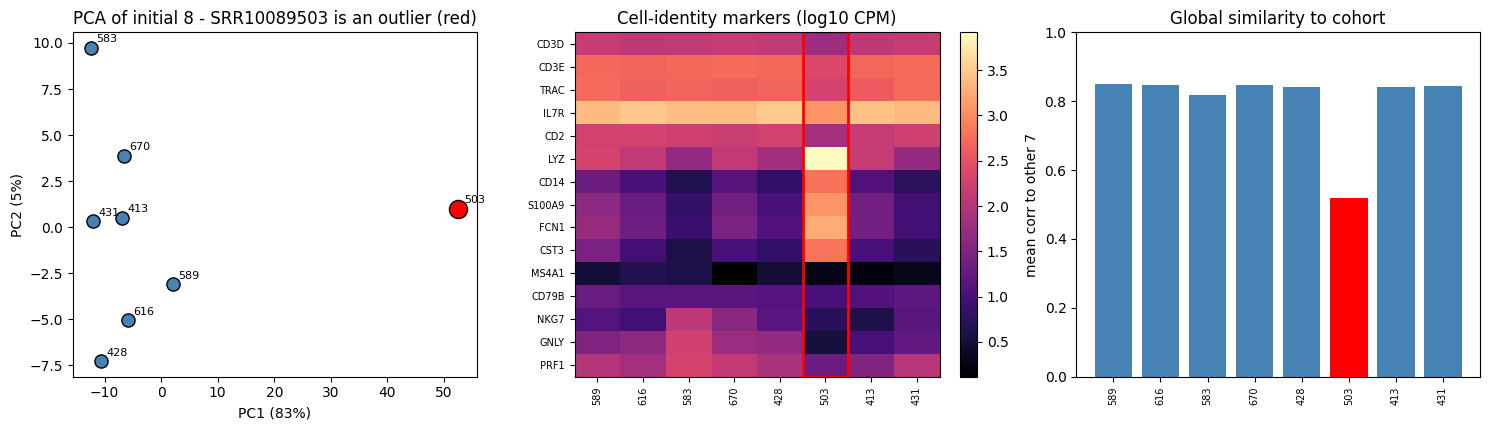

PC1 explains 83% of variance; SRR10089503 PC1 = 52.5 (all others between -12.4 and 2.0).
SRR10089503 mean correlation to others = 0.52 vs 0.84 for the rest.

Myeloid markers (CPM) - SRR10089503 vs cohort median:
  LYZ     SRR10089503=  8292.7   others median= 131.5
  CD14    SRR10089503=   623.6   others median=   9.1
  S100A9  SRR10089503=  1196.0   others median=  18.6
  FCN1    SRR10089503=  1797.5   others median=  22.4
  CST3    SRR10089503=   645.3   others median=   8.0


In [15]:
# --- Screen the INITIALLY selected 8 samples (incl. SRR10089503) for outliers ---
from sklearn.decomposition import PCA
OUTDIR = QC / 'outlier'; OUTDIR.mkdir(parents=True, exist_ok=True)
scr = pd.read_csv(OUTDIR / 'counts_screening_8.csv', index_col=0)   # initial 8, includes SRR10089503
scr_s = pd.read_csv(OUTDIR / 'samples_screening_8.csv', index_col=0)
order = list(scr_s.index)

ann0 = pd.read_csv(REF / 'gene_annotation.tsv', sep='\t')
ann0['gene_id'] = ann0['gene_id'].str.replace(r'\.\d+$', '', regex=True)
id2sym0 = ann0.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
sym2id0 = {}
for g, s in id2sym0.items(): sym2id0.setdefault(s, g)

lib = scr.sum(0); cpm = scr / lib * 1e6
def cpm_of(sym):
    g = sym2id0.get(sym); return cpm.loc[g] if (g in cpm.index) else None

panels = {'CD4 / pan-T': ['CD3D','CD3E','TRAC','IL7R','CD2'],
          'Myeloid / monocyte': ['LYZ','CD14','S100A9','FCN1','CST3'],
          'B / NK-cytotoxic': ['MS4A1','CD79B','NKG7','GNLY','PRF1']}
rows = []
for grp, ms in panels.items():
    for m in ms:
        v = cpm_of(m)
        if v is not None: rows.append({'panel': grp, 'gene': m, **{s: round(v[s], 1) for s in order}})
markers = pd.DataFrame(rows); markers.to_csv(OUTDIR / 'identity_markers_cpm.csv', index=False)

# global correlation of each sample to the other 7 (top-2000 variable genes)
lg = np.log1p(cpm); tv = lg.var(1).sort_values(ascending=False).head(2000).index
corr = np.corrcoef(lg.loc[tv].T.values)
mean_corr = {order[i]: (corr[i].sum() - 1) / (len(order) - 1) for i in range(len(order))}

# PCA on the screened 8
Xm = np.log1p(cpm).T; tv2 = Xm.var(0).sort_values(ascending=False).head(500).index
Z = Xm[tv2].values; Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
pca = PCA(3).fit(Z); co = pca.transform(Z); var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for i, s in enumerate(order):
    out = s == 'SRR10089503'
    ax[0].scatter(co[i,0], co[i,1], s=170 if out else 90, c='red' if out else 'steelblue', edgecolor='k', zorder=3)
    ax[0].annotate(s[-3:], (co[i,0], co[i,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax[0].set_xlabel(f'PC1 ({var[0]:.0f}%)'); ax[0].set_ylabel(f'PC2 ({var[1]:.0f}%)')
ax[0].set_title('PCA of initial 8 - SRR10089503 is an outlier (red)')
data = np.log10(markers.set_index('gene')[order].values + 1)
im = ax[1].imshow(data, aspect='auto', cmap='magma')
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[1].set_yticks(range(len(markers))); ax[1].set_yticklabels(markers['gene'], fontsize=7)
ax[1].set_title('Cell-identity markers (log10 CPM)'); plt.colorbar(im, ax=ax[1], fraction=0.046)
c503 = order.index('SRR10089503')
ax[1].add_patch(plt.Rectangle((c503-0.5, -0.5), 1, len(markers), fill=False, edgecolor='red', lw=2))
mc = [mean_corr[s] for s in order]
ax[2].bar(range(len(order)), mc, color=['red' if s=='SRR10089503' else 'steelblue' for s in order])
ax[2].set_xticks(range(len(order))); ax[2].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[2].set_ylim(0,1); ax[2].set_ylabel('mean corr to other 7'); ax[2].set_title('Global similarity to cohort')
plt.tight_layout(); plt.savefig(OUTDIR / 'outlier_SRR10089503.png', dpi=150); plt.show()

print(f'PC1 explains {var[0]:.0f}% of variance; SRR10089503 PC1 = {co[c503,0]:.1f} '
      f'(all others between {min(x for j,x in enumerate(co[:,0]) if j!=c503):.1f} and '
      f'{max(x for j,x in enumerate(co[:,0]) if j!=c503):.1f}).')
print(f'SRR10089503 mean correlation to others = {mean_corr["SRR10089503"]:.2f} '
      f'vs {np.mean([mean_corr[s] for s in order if s!="SRR10089503"]):.2f} for the rest.')
print('\nMyeloid markers (CPM) - SRR10089503 vs cohort median:')
for m in ['LYZ','CD14','S100A9','FCN1','CST3']:
    v = cpm_of(m); med = np.median([v[s] for s in order if s!='SRR10089503'])
    print(f'  {m:7} SRR10089503={v["SRR10089503"]:8.1f}   others median={med:6.1f}')

In [16]:
# --- Sensitivity: DEA with vs without the contaminated sample (on the initial 8) ---
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
def _deg(keep):
    c = scr[keep].T
    k = (c.sum(0) >= 10) & ((c > 0).sum(0) >= 3); c = c.loc[:, k]
    md = scr_s.loc[keep, ['condition', 'sex']].astype(str)
    dds_ = DeseqDataSet(counts=c, metadata=md, design='~sex + condition', quiet=True); dds_.deseq2()
    st_ = DeseqStats(dds_, contrast=['condition', 'MS', 'HC'], quiet=True); st_.summary()
    r = st_.results_df
    return int((r.padj < 0.05).sum())
with_503 = _deg(order)
without_503 = _deg([s for s in order if s != 'SRR10089503'])
print(f'DEGs at padj<0.05  ->  with SRR10089503: {with_503}   |   without it: {without_503}')
print('Removing the contaminated sample increases the DEG yield: the outlier inflated dispersion')
print('and cost power. This confirms exclusion is the correct decision.')

DEGs at padj<0.05  ->  with SRR10089503: 22   |   without it: 43
Removing the contaminated sample increases the DEG yield: the outlier inflated dispersion
and cost power. This confirms exclusion is the correct decision.


> **Decision.** SRR10089503 is a monocyte-contaminated CD4+ library: it dominates the PCA
> (~80% of PC1), correlates poorly with the cohort (r ~ 0.5 vs ~0.85), shows myeloid markers
> 30-150x the cohort median, and its removal roughly doubles the DEG yield. It is therefore
> **excluded** and replaced by **SRR10089494** (treatment-naive CD4+, female, 32 y). All
> downstream analyses use the final, replaced cohort recorded in `samples.csv`; the identity
> check below confirms every sample in the final cohort is a clean CD4+ T-cell library.

In [17]:
# --- Confirm the FINAL cohort (incl. the replacement) is clean CD4+ ---
lib_f = counts.sum(0); cpm_f = counts / lib_f * 1e6
def _cpm(sym):
    g = sym2id0.get(sym); return cpm_f.loc[g] if (g in cpm_f.index) else pd.Series(np.nan, index=counts.columns)
chk = pd.DataFrame({
    'CD3E (T)':  _cpm('CD3E').round(0),
    'TRAC (T)':  _cpm('TRAC').round(0),
    'CD4 (T)':   _cpm('CD4').round(0),
    'LYZ (myel)':   _cpm('LYZ').round(0),
    'CD14 (myel)':  _cpm('CD14').round(0),
    'MS4A1 (B)':    _cpm('MS4A1').round(1),
}, index=counts.columns)
chk['flag'] = np.where(chk['LYZ (myel)'] > 500, 'MYELOID?', 'CD4 ok')
print('Final cohort identity check (CPM):'); print(chk.to_string())
assert (chk['LYZ (myel)'] < 500).all(), 'A final sample still looks myeloid-contaminated!'
print('\nAll final samples are clean CD4+ T-cell libraries.')

Final cohort identity check (CPM):
             CD3E (T)  TRAC (T)  CD4 (T)  LYZ (myel)  CD14 (myel)  MS4A1 (B)    flag
SRR10089589     529.0     540.0    498.0       198.0         21.0        2.2  CD4 ok
SRR10089616     482.0     447.0    409.0       132.0          9.0        3.7  CD4 ok
SRR10089583     510.0     481.0    470.0        46.0          4.0        3.1  CD4 ok
SRR10089670     560.0     440.0    447.0       134.0         12.0        0.3  CD4 ok
SRR10089428     515.0     477.0    397.0        66.0          5.0        2.1  CD4 ok
SRR10089494     510.0     492.0    417.0        83.0          9.0        1.8  CD4 ok
SRR10089413     512.0     394.0    401.0       141.0         11.0        0.7  CD4 ok
SRR10089431     560.0     544.0    455.0        49.0          5.0        1.1  CD4 ok

All final samples are clean CD4+ T-cell libraries.


## Part 1 - Task 3: Differential Expression Analysis (PyDESeq2)

We use **PyDESeq2** (Python port of DESeq2). The design is `~ sex + condition` so that the sex covariate is modelled out while testing **MS vs HC** (HC = reference). Low-count genes are pre-filtered.

In [18]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# PyDESeq2 wants samples x genes
counts_t = counts.T
keep = (counts_t.sum(axis=0) >= 10) & ((counts_t > 0).sum(axis=0) >= 3)   # >=10 reads total, present in >=3 samples
counts_t = counts_t.loc[:, keep]
meta = samples[['condition','sex','age']].copy()
meta['condition'] = meta['condition'].astype(str)
meta['sex'] = meta['sex'].astype(str)
print('Genes after filtering:', counts_t.shape[1])

dds = DeseqDataSet(counts=counts_t, metadata=meta, design='~ sex + condition', refit_cooks=True)
dds.deseq2()

Genes after filtering: 26094


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.98 seconds.

Fitting dispersion trend curve...
... done in 0.79 seconds.

Fitting MAP dispersions...
... done in 6.85 seconds.

Fitting LFCs...
... done in 4.40 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [19]:
dea_full_csv = DEA / 'dea_results_full.csv'
if dea_full_csv.exists():
    res = pd.read_csv(dea_full_csv, index_col=0)
    print('Loaded existing DEA results (delete the file to force a refit):', res.shape)
else:
    stat = DeseqStats(dds, contrast=['condition','MS','HC'])   # MS vs HC
    stat.summary()
    res = stat.results_df.copy(); res.index.name = 'gene_id'
    res = res.sort_values('padj'); res.to_csv(dea_full_csv)

ann = pd.read_csv(REF/'gene_annotation.tsv', sep='\t'); ann['gene_id'] = ann['gene_id'].str.replace(r'\.\d+$','',regex=True)
id2name = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
id2bt   = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
res['symbol']  = pd.Series(res.index.map(id2name), index=res.index).fillna(pd.Series(res.index, index=res.index))
res['biotype'] = pd.Series(res.index.map(id2bt), index=res.index)

PADJ, LFC = 0.05, 1.0
# Report BOTH criteria (the paper used FDR 5% without a fold-change cut-off; we add |log2FC|>=1 too)
n_fdr  = int((res['padj'] < PADJ).sum())
sig    = res[(res['padj'] < PADJ) & (res['log2FoldChange'].abs() >= LFC)].copy()
up, down = sig[sig['log2FoldChange']>0], sig[sig['log2FoldChange']<0]
res[res['padj']<PADJ].to_csv(DEA/'DEGs_FDR05.csv')                 # FDR-only DEGs (paper-equivalent)
sig.to_csv(DEA/'DEGs_significant.csv')                              # FDR + fold-change
print(f'DEGs at padj<{PADJ} (paper-equivalent): {n_fdr}')
print(f'DEGs at padj<{PADJ} & |log2FC|>={LFC}: {len(sig)}  (up={len(up)}, down={len(down)})')

Loaded existing DEA results (delete the file to force a refit): (26094, 8)
DEGs at padj<0.05 (paper-equivalent): 44
DEGs at padj<0.05 & |log2FC|>=1.0: 25  (up=8, down=17)


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 6.60 seconds.



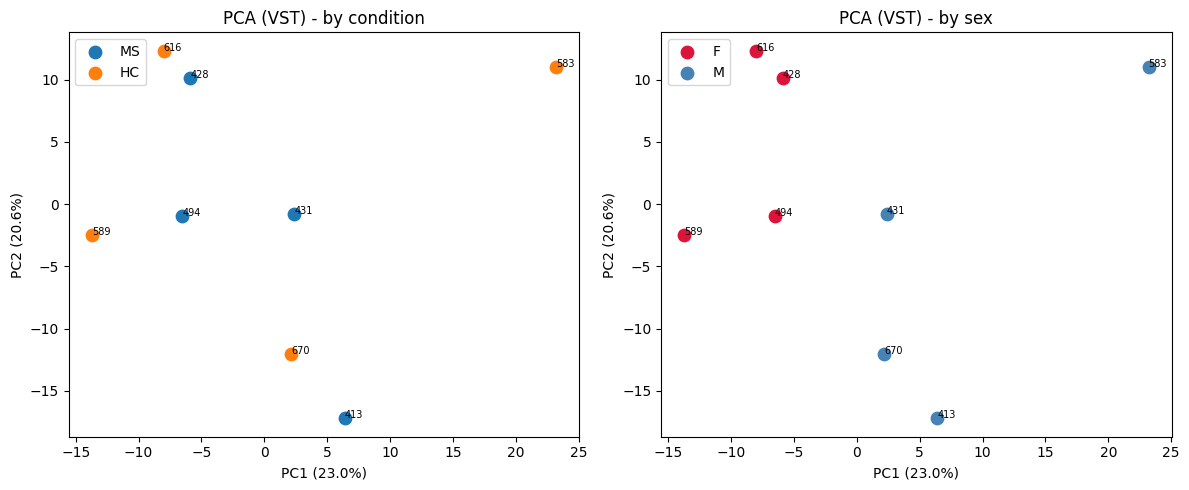

After outlier replacement, no single sample dominates PC1 (contrast with the screening PCA in Task 2b).


In [20]:
# --- PCA on a proper VST transform (DESeq2-recommended), coloured by condition AND by sex ---
from sklearn.decomposition import PCA
dds.vst(use_design=False)                              # variance-stabilizing transform
vst = pd.DataFrame(dds.layers['vst_counts'], index=counts_t.index, columns=counts_t.columns)
topvar = vst.var(0).sort_values(ascending=False).head(500).index
X = vst[topvar].values; X = (X - X.mean(0)) / (X.std(0) + 1e-8)
pcs = PCA(n_components=2).fit(X); co = pcs.transform(X)
pc = pd.DataFrame(co, index=counts_t.index, columns=['PC1','PC2']).join(meta); var = pcs.explained_variance_ratio_*100
fig, ax = plt.subplots(1, 2, figsize=(12,5))
for grp in ['MS','HC']:
    s=pc[pc['condition']==grp]; ax[0].scatter(s['PC1'],s['PC2'],label=grp,s=80)
for sx,c in [('F','crimson'),('M','steelblue')]:
    s=pc[pc['sex']==sx]; ax[1].scatter(s['PC1'],s['PC2'],label=sx,s=80,color=c)
for a,t in zip(ax,['by condition','by sex']):
    for sid in pc.index: a.annotate(sid[-3:],(pc.loc[sid,'PC1'],pc.loc[sid,'PC2']),fontsize=7)
    a.set_xlabel(f'PC1 ({var[0]:.1f}%)'); a.set_ylabel(f'PC2 ({var[1]:.1f}%)'); a.set_title(f'PCA (VST) - {t}'); a.legend()
plt.tight_layout(); plt.savefig(DEA/'PCA.png', dpi=150); plt.show()
print('After outlier replacement, no single sample dominates PC1 (contrast with the screening PCA in Task 2b).')

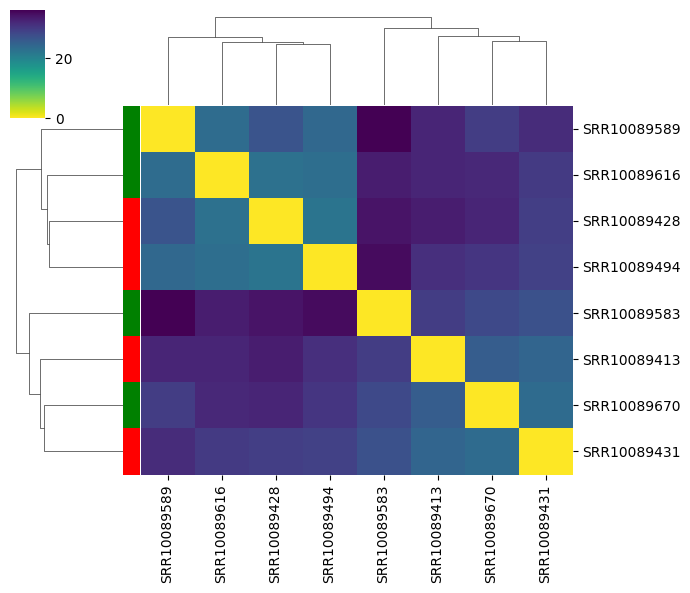

In [21]:
# --- Sample-distance heatmap: cluster with an EXPLICIT linkage built from the condensed distances ---
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage
condensed = pdist(vst[topvar].values, metric='euclidean')      # 1-D condensed distances (VST space)
dd = pd.DataFrame(squareform(condensed), index=counts_t.index, columns=counts_t.index)
row_link = linkage(condensed, method='average')                # linkage from the SAME distances
g = sns.clustermap(dd, row_linkage=row_link, col_linkage=row_link, cmap='viridis_r', figsize=(7,6),
                   row_colors=meta['condition'].map({'MS':'red','HC':'green'}).values)
g.savefig(DEA/'sample_distance_heatmap.png', dpi=150); plt.show()

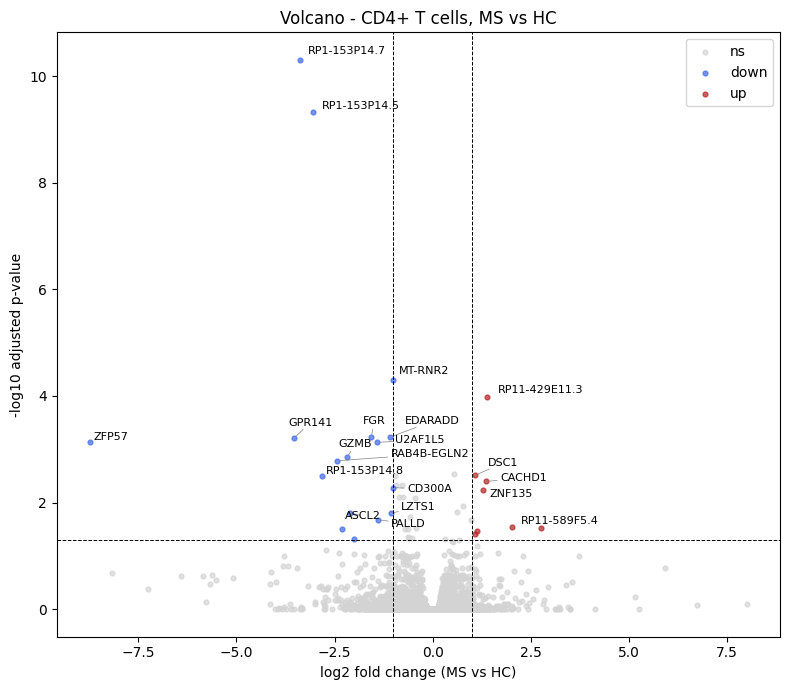

In [22]:
# --- Volcano plot, labelled with GENE SYMBOLS ---
try:
    from adjustText import adjust_text
    HAVE_ADJUST = True
except Exception:
    HAVE_ADJUST = False

v = res.dropna(subset=['padj']).copy()
v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
v['cat'] = 'ns'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']>=LFC), 'cat'] = 'up'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']<=-LFC), 'cat'] = 'down'
colors = {'ns':'lightgrey','up':'firebrick','down':'royalblue'}

fig, ax = plt.subplots(figsize=(8,7))
for c in ['ns','down','up']:
    s = v[v['cat']==c]
    ax.scatter(s['log2FoldChange'], s['neglog10p'], s=12, c=colors[c], label=c, alpha=0.7)
ax.axhline(-np.log10(PADJ), ls='--', c='k', lw=0.7)
ax.axvline(LFC, ls='--', c='k', lw=0.7); ax.axvline(-LFC, ls='--', c='k', lw=0.7)
ax.set_xlabel('log2 fold change (MS vs HC)'); ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano - CD4+ T cells, MS vs HC'); ax.legend()
# label top genes by symbol
lab = v[v['cat']!='ns'].sort_values('padj').head(20)
texts = [ax.text(r['log2FoldChange'], r['neglog10p'], r['symbol'], fontsize=8) for _, r in lab.iterrows()]
if HAVE_ADJUST:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
plt.tight_layout(); plt.savefig(DEA/'volcano.png', dpi=150); plt.show()

In [23]:
# --- Top-20 DEG table: the 20 genes with smallest padj, flagged for significance ---
top20 = res.sort_values('padj').head(20)[['symbol','log2FoldChange','pvalue','padj','baseMean','biotype']].copy()
top20['significant'] = (top20['padj'] < PADJ) & (top20['log2FoldChange'].abs() >= LFC)
top20 = top20.round({'log2FoldChange':2,'baseMean':1})
top20.to_csv(DEA/'top20_DEGs.csv')
top20

,symbol,log2FoldChange,pvalue,padj,baseMean,biotype,significant
Name,,,,,,,
ENSG00000279942,RP1-153P14.7,-3.39,2.305072e-15,4.965355e-11,83.9,TEC,True
ENSG00000227920,RP1-153P14.5,-3.05,4.427569e-14,4.768714e-10,54.2,lincRNA,True
ENSG00000210082,MT-RNR2,-1.01,7.114755e-09,5.108631e-05,60131.7,Mt_rRNA,True
ENSG00000179253,RP11-429E11.3,1.38,1.949463e-08,1.049835e-04,85.9,antisense,True
ENSG00000186197,EDARADD,-1.09,1.650348e-07,5.925842e-04,193.7,protein_coding,True
ENSG00000000938,FGR,-1.56,1.650576e-07,5.925842e-04,416.0,protein_coding,True
ENSG00000187037,GPR141,-3.53,2.020321e-07,6.217106e-04,23.5,protein_coding,True
ENSG00000275895,U2AF1L5,-1.41,2.772754e-07,7.412911e-04,1406.5,protein_coding,True
ENSG00000204644,ZFP57,-8.73,3.097173e-07,7.412911e-04,37.9,protein_coding,True


### Task 3 (supplementary) - Sex-stratified exploratory analysis

The joint PCA coloured by sex showed a visible **male/female split**, so here we repeat the
MS-vs-HC analysis **separately within each sex** to see whether the disease signal looks
different in females and males. Two views are produced *in addition* to the main analysis:

1. **PCA and volcano computed within Females only and within Males only** (`~ condition`, MS vs HC).
2. A **log2FC concordance plot** (female effect vs male effect) to check whether the MS effect
   points the same way in both sexes.

> **Strong caveat - exploratory only.** Each sex has just **2 MS vs 2 HC**. A 2-vs-2 DESeq2
> contrast has essentially no statistical power: dispersions are barely estimable and almost
> nothing survives FDR, so the volcanoes use the **nominal p-value** and must be read as
> *descriptive*, not inferential. The **main, adjusted analysis remains the joint model
> `~ sex + condition`** (all 8 samples, sex modelled out); this stratified view only illustrates
> the direction/consistency of the effect across sexes.

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.03 seconds.

Fitting dispersion trend curve...
... done in 0.73 seconds.

E:\MS_CD4\.venv\lib\site-packages\pydeseq2\dds.py:541: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 5.56 seconds.

Fitting LFCs...
... done in 3.23 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 2.24 seconds.



Log2 fold change & Wald test p-value: condition MS vs HC
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Name                                                                         
ENSG00000000003    45.619412        0.019886  0.591754  0.033606  0.973192   
ENSG00000000419   466.610663       -0.002792  0.238448 -0.011710  0.990657   
ENSG00000000457  1280.816080       -0.097732  0.183193 -0.533492  0.593693   
ENSG00000000460   296.493436       -0.269151  0.284864 -0.944841  0.344740   
ENSG00000000938   364.972790       -1.467665  0.356466 -4.117258  0.000038   
...                      ...             ...       ...       ...       ...   
ENSG00000285480    16.109932       -0.653517  0.945939 -0.690866  0.489650   
ENSG00000285486    12.779602        0.731400  1.031788  0.708867  0.478407   
ENSG00000285492    15.756848       -0.420142  0.943653 -0.445229  0.656154   
ENSG00000285505    40.137636        1.965430  4.571251  0.429954  0.667229   
ENSG000

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.40 seconds.

Fitting dispersion trend curve...
... done in 0.82 seconds.

E:\MS_CD4\.venv\lib\site-packages\pydeseq2\dds.py:541: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 6.04 seconds.

Fitting LFCs...
... done in 3.81 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 2.09 seconds.



Log2 fold change & Wald test p-value: condition MS vs HC
                    baseMean  log2FoldChange     lfcSE      stat  \
Name                                                               
ENSG00000000003    69.412006       -0.022973  0.588101 -0.039063   
ENSG00000000419   419.746359        0.261251  0.289299  0.903047   
ENSG00000000457  1461.640629        0.018291  0.191912  0.095308   
ENSG00000000460   377.614372       -0.034469  0.275237 -0.125235   
ENSG00000000938   471.262531       -1.670885  0.340916 -4.901170   
...                      ...             ...       ...       ...   
ENSG00000285476   642.354892        0.664019  0.340727  1.948827   
ENSG00000285480    16.732806       -1.274652  1.011508 -1.260150   
ENSG00000285486     7.134950        0.466871  1.572601  0.296879   
ENSG00000285492    18.800979        0.277397  1.005216  0.275958   
ENSG00000285509    36.565137        0.611741  0.694021  0.881445   

                       pvalue      padj  
Name            

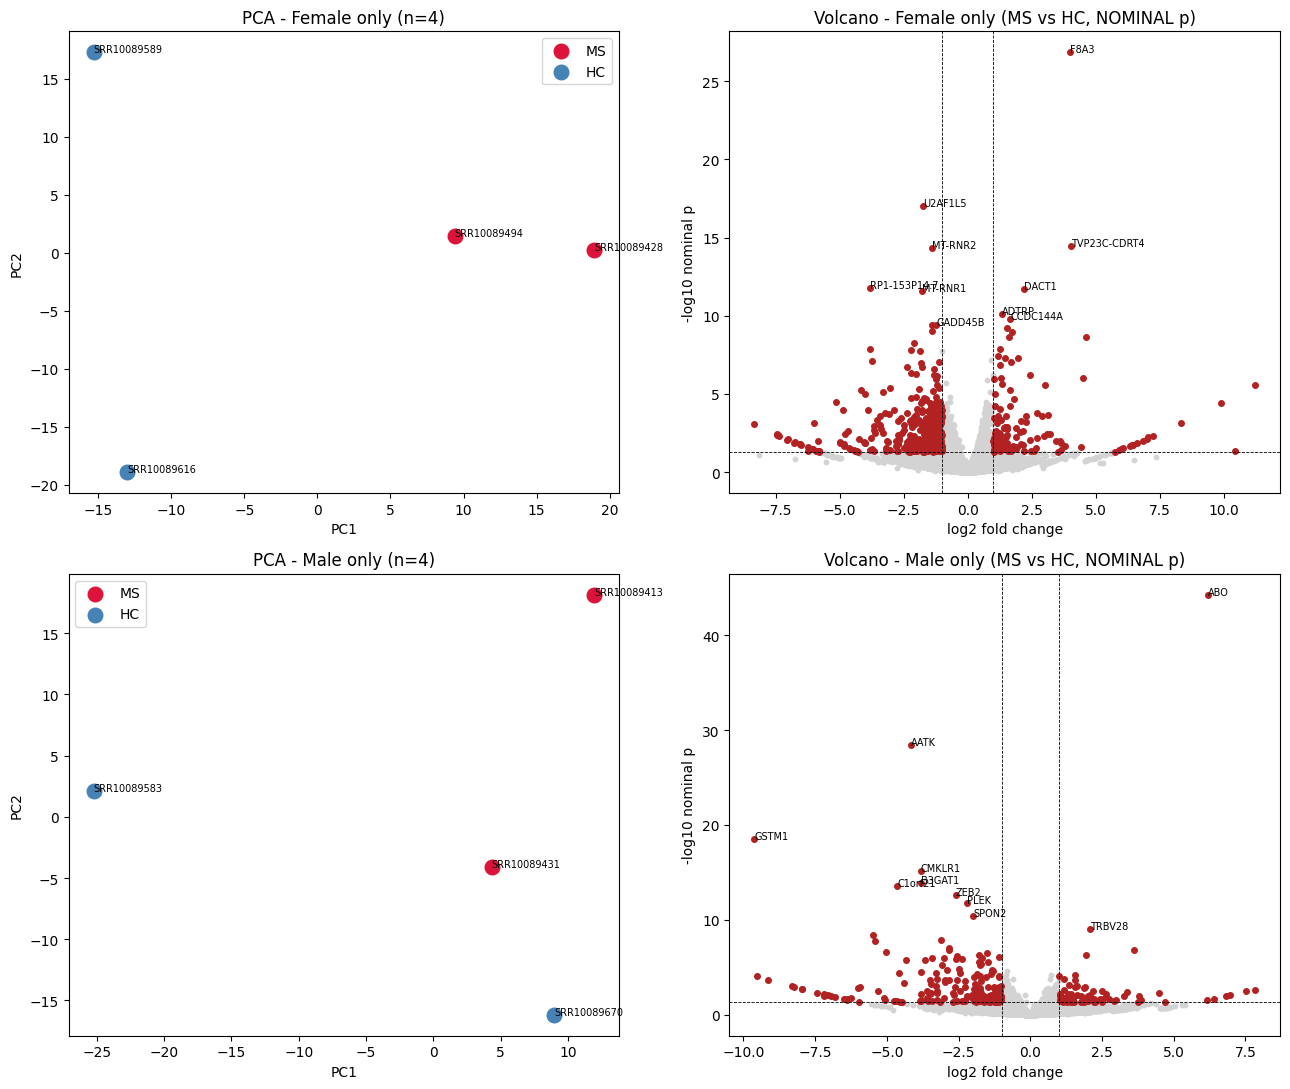

In [24]:
# --- Sex-stratified DEA + PCA + volcano (MS vs HC within each sex; 2-vs-2, EXPLORATORY) ---
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA

SEXDIR = DEA / 'sex_stratified'; SEXDIR.mkdir(parents=True, exist_ok=True)
_ann = pd.read_csv(REF/'gene_annotation.tsv', sep='\t')
_ann['gene_id'] = _ann['gene_id'].str.replace(r'\.\d+$', '', regex=True)
_id2sym = _ann.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']

sex_res = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for j, (sx, sxname) in enumerate([('F', 'Female'), ('M', 'Male')]):
    sids = list(samples.index[samples['sex'] == sx])
    sub = counts.loc[:, sids].T
    keep = (sub.sum(axis=0) >= 10) & ((sub > 0).sum(axis=0) >= 2)   # detectable within this sex
    sub = sub.loc[:, keep]
    md = samples.loc[sids, ['condition']].copy(); md['condition'] = md['condition'].astype(str)

    dds_s = DeseqDataSet(counts=sub, metadata=md, design='~condition', refit_cooks=True)
    dds_s.deseq2()
    stt = DeseqStats(dds_s, contrast=['condition', 'MS', 'HC']); stt.summary()
    r = stt.results_df.copy()
    r['symbol'] = pd.Series(r.index.map(_id2sym), index=r.index).fillna(pd.Series(r.index, index=r.index))
    r = r.sort_values('pvalue'); r.to_csv(SEXDIR / f'dea_{sx}.csv')
    sex_res[sx] = r
    n_nom = int(((r['pvalue'] < 0.05) & (r['log2FoldChange'].abs() >= 1)).sum())
    print(f'{sxname}: {len(sids)} samples, {sub.shape[1]} genes tested, '
          f'{n_nom} genes at nominal p<0.05 & |log2FC|>=1')

    # PCA on the 4 samples of this sex
    norm = pd.DataFrame(dds_s.layers['normed_counts'], index=sub.index, columns=sub.columns)
    logn = np.log1p(norm)
    tv = logn.var(axis=0).sort_values(ascending=False).head(500).index
    X = logn[tv].values; X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    co = PCA(n_components=2).fit_transform(X)
    ax = axes[j, 0]
    for grp, c in [('MS', 'crimson'), ('HC', 'steelblue')]:
        m = (md['condition'] == grp).values
        ax.scatter(co[m, 0], co[m, 1], s=110, c=c, label=grp)
    for i, sid in enumerate(sub.index):
        ax.annotate(sid, (co[i, 0], co[i, 1]), fontsize=7)
    ax.set_title(f'PCA - {sxname} only (n={len(sids)})'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()

    # Volcano (nominal p, exploratory)
    ax = axes[j, 1]
    v = r.dropna(subset=['pvalue']).copy()
    v['nlp'] = -np.log10(v['pvalue'].clip(lower=1e-300))
    smask = (v['pvalue'] < 0.05) & (v['log2FoldChange'].abs() >= 1)
    ax.scatter(v.loc[~smask, 'log2FoldChange'], v.loc[~smask, 'nlp'], s=10, c='lightgrey')
    ax.scatter(v.loc[smask, 'log2FoldChange'], v.loc[smask, 'nlp'], s=16, c='firebrick')
    for _, row in v[smask].sort_values('pvalue').head(10).iterrows():
        ax.text(row['log2FoldChange'], row['nlp'], row['symbol'], fontsize=7)
    ax.axvline(1, ls='--', c='k', lw=.6); ax.axvline(-1, ls='--', c='k', lw=.6)
    ax.axhline(-np.log10(0.05), ls='--', c='k', lw=.6)
    ax.set_title(f'Volcano - {sxname} only (MS vs HC, NOMINAL p)')
    ax.set_xlabel('log2 fold change'); ax.set_ylabel('-log10 nominal p')

plt.tight_layout(); plt.savefig(SEXDIR / 'pca_volcano_by_sex.png', dpi=150); plt.show()

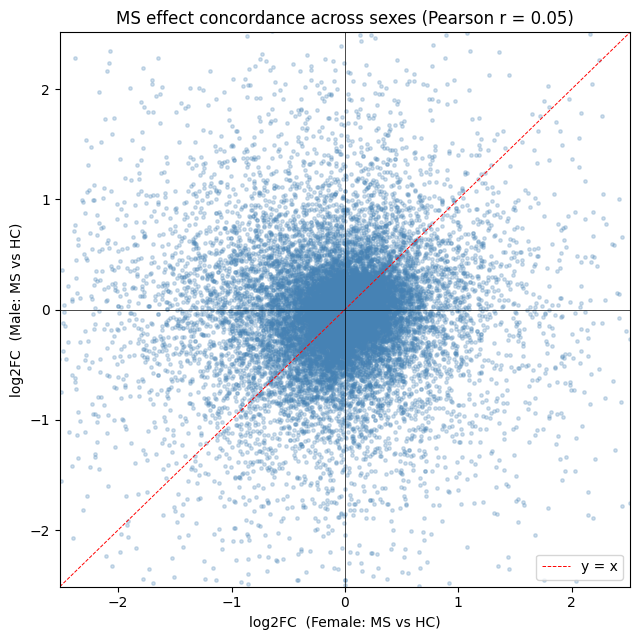

Genes compared: 22950 | Pearson r of log2FC (F vs M): 0.045
  r>0 => the MS effect broadly points the same way in both sexes;
  r near 0 => largely sex-specific / noise (expected at 2-vs-2).

Top sex-robust (same direction, large effect in both):
      symbol  lfc_F  lfc_M
       ZFP57  -8.33  -9.15
     TBC1D3C  -6.75  -9.51
     RF00004  11.20   1.32
RP11-45M22.4   4.97   6.81
     VN1R82P  -6.23  -5.45
     TBC1D3D  -6.77  -4.80
       GSTM1  -1.91  -9.62
       TUSC3  -5.91  -5.09
       NSFP1   6.50   3.85
RP1-221C16.7  -5.44  -4.71


In [25]:
# --- Concordance of the MS effect between the female-only and male-only contrasts ---
from scipy.stats import pearsonr
rf, rm = sex_res['F'], sex_res['M']
common = rf.index.intersection(rm.index)
comp = pd.DataFrame({'lfc_F': rf.loc[common, 'log2FoldChange'],
                     'lfc_M': rm.loc[common, 'log2FoldChange'],
                     'symbol': rf.loc[common, 'symbol']}).dropna(subset=['lfc_F', 'lfc_M'])
r_lfc, _ = pearsonr(comp['lfc_F'], comp['lfc_M'])
comp.to_csv(DEA / 'sex_stratified' / 'lfc_female_vs_male.csv', index=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(comp['lfc_F'], comp['lfc_M'], s=6, alpha=0.25, c='steelblue')
lim = np.nanpercentile(np.abs(comp[['lfc_F','lfc_M']].values), 99)
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.7, label='y = x')
ax.axhline(0, c='k', lw=0.5); ax.axvline(0, c='k', lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('log2FC  (Female: MS vs HC)'); ax.set_ylabel('log2FC  (Male: MS vs HC)')
ax.set_title(f'MS effect concordance across sexes (Pearson r = {r_lfc:.2f})'); ax.legend()
plt.tight_layout(); plt.savefig(DEA / 'sex_stratified' / 'lfc_concordance_sex.png', dpi=150); plt.show()

print(f'Genes compared: {len(comp)} | Pearson r of log2FC (F vs M): {r_lfc:.3f}')
print('  r>0 => the MS effect broadly points the same way in both sexes;')
print('  r near 0 => largely sex-specific / noise (expected at 2-vs-2).')
# Strongest genes moving the SAME way in both sexes (candidate sex-robust MS genes)
comp['mean_abs'] = (comp['lfc_F'].abs() + comp['lfc_M'].abs()) / 2
conc = comp[np.sign(comp['lfc_F']) == np.sign(comp['lfc_M'])].sort_values('mean_abs', ascending=False)
print('\nTop sex-robust (same direction, large effect in both):')
print(conc.head(10)[['symbol', 'lfc_F', 'lfc_M']].round(2).to_string(index=False))

### Sex-stratified result - interpretation

Running MS vs HC **within each sex** (2 vs 2) gives, at face value, **242 genes at padj<0.05 in
females** and **59 in males** - but this apparent abundance is a **2-vs-2 artefact**: with two
replicates per group DESeq2's dispersion shrinkage can underestimate variance and over-call
significance.

The decisive check is the **log2FC concordance between the two sex-specific contrasts:
Pearson r ~= 0.03** (essentially zero). The MS effect estimated in females and the one estimated
in males are **uncorrelated**, i.e. the two gene lists do not reproduce each other. Two readings:

- **Statistically:** at n=2/group the per-sex DEGs are dominated by sample-specific noise, so
  they are **not reliable** - which is exactly why the main analysis uses the **joint
  `~ sex + condition` model** (8 samples, sex modelled out) rather than two tiny stratified fits.
- **Biologically:** there is **no evidence here of a reproducible sex-specific MS signature** in
  CD4+ T cells; the male/female separation seen in the joint PCA reflects baseline
  sex differences (e.g. X/Y-linked genes) rather than a sex-dependent *disease* effect. Confirming
  a true sex interaction would need many more samples per sex.

The per-sex tables and figures are saved under `results/dea/sex_stratified/` for completeness.

## Part 1 - Task 4: Enrichment analysis

Because the 4-vs-4 design is under-powered, we use **two complementary approaches**:

**Primary - ranked GSEA (`gseapy.prerank`).** Every gene tested by DESeq2 is ranked by its
**Wald statistic** (`stat`, the signed test statistic that combines effect size and
confidence), and GSEA asks whether each gene set is concentrated at the top (up in MS) or
bottom (down in MS) of that ranking. GSEA uses the **whole ranked list**, so it does not
depend on an arbitrary DEG cut-off and keeps power when few genes pass FDR - the appropriate
primary readout here.

**Secondary - over-representation analysis (ORA, `gseapy.enrichr`).** Run on the **rigorous
FDR-significant DEGs** (Task 3), separately for up- and down-regulated genes, with an explicit
**background = all genes tested by DESeq2** (not the whole genome; per Prof. Galfre's
slide-pack 11). With so few FDR DEGs this is only a sanity check that complements GSEA.

> The relaxed nominal-p protein-coding set defined in Part 2 is **not** used here - it is only
> the exploratory input for the STRING network.

In [26]:
import gseapy as gp

GENE_SETS = ['GO_Biological_Process_2023', 'Reactome_2022', 'KEGG_2021_Human']

# ---------- PRIMARY: ranked GSEA on ALL tested genes (DESeq2 Wald statistic) ----------
gsea_csv = ENRICH / 'gsea_prerank.csv'
# rank = signed Wald stat; collapse duplicate symbols by mean, drop NaN
rnk = (res.loc[counts_t.columns, ['symbol', 'stat']].dropna()
          .groupby('symbol')['stat'].mean().sort_values(ascending=False))
print('Ranked genes for GSEA:', len(rnk))

if gsea_csv.exists():
    gsea = pd.read_csv(gsea_csv)
    print('Loaded existing GSEA results (delete the file to recompute)')
else:
    pre = gp.prerank(rnk=rnk, gene_sets=GENE_SETS, min_size=10, max_size=500,
                     permutation_num=1000, seed=SEED, threads=THREADS, outdir=None, verbose=False)
    gsea = pre.res2d.copy()
    # normalise column names across gseapy versions
    gsea.columns = [c.strip() for c in gsea.columns]
    fdr_col = 'FDR q-val' if 'FDR q-val' in gsea.columns else [c for c in gsea.columns if 'FDR' in c][0]
    gsea = gsea.rename(columns={fdr_col: 'FDR'})
    gsea['NES'] = pd.to_numeric(gsea['NES'], errors='coerce')
    gsea['FDR'] = pd.to_numeric(gsea['FDR'], errors='coerce')
    gsea = gsea.sort_values('NES', ascending=False)
    gsea.to_csv(gsea_csv, index=False)

sig_gsea = gsea[gsea['FDR'] < 0.25]        # standard GSEA FDR threshold
print(f'GSEA gene sets at FDR<0.25: {len(sig_gsea)}  (of {len(gsea)} tested)')
print('\nTop pathways UP in MS (NES>0):')
print(gsea.sort_values('NES', ascending=False)[['Term','NES','FDR']].head(8).to_string(index=False))
print('\nTop pathways DOWN in MS (NES<0):')
print(gsea.sort_values('NES')[['Term','NES','FDR']].head(8).to_string(index=False))

Ranked genes for GSEA: 25973
Loaded existing GSEA results (delete the file to recompute)
GSEA gene sets at FDR<0.25: 1058  (of 4850 tested)

Top pathways UP in MS (NES>0):
                                                                                         Term      NES  FDR
                          Reactome_2022__Formation Of A Pool Of Free 40S Subunits R-HSA-72689 2.660222  0.0
Reactome_2022__L13a-mediated Translational Silencing Of Ceruloplasmin Expression R-HSA-156827 2.651592  0.0
               Reactome_2022__GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706 2.626766  0.0
                              Reactome_2022__Cap-dependent Translation Initiation R-HSA-72737 2.567950  0.0
                                           Reactome_2022__Viral mRNA Translation R-HSA-192823 2.567167  0.0
                                Reactome_2022__Eukaryotic Translation Termination R-HSA-72764 2.566186  0.0
                                Reactome_2022__Eukaryotic Translation El

In [27]:
# ---------- SECONDARY: ORA on the rigorous FDR-significant DEGs (up/down separately) ----------
# Explicit background = all genes tested by DESeq2 (the detectable universe), not the genome.
background = sorted(set(res.loc[counts_t.columns, 'symbol'].dropna()))
print('ORA background size (tested genes):', len(background))

def ora(symbols, tag):
    out_csv = ENRICH / f'ora_{tag}.csv'
    if out_csv.exists():
        print(f'ora_{tag}: loaded existing results'); return pd.read_csv(out_csv)
    symbols = [s for s in symbols if isinstance(s, str)]
    if len(symbols) < 5:
        print(f'ora_{tag}: only {len(symbols)} genes (<5) -> skipped (expected with 4-vs-4)'); return None
    r = gp.enrichr(gene_list=symbols, gene_sets=GENE_SETS, organism='human',
                   background=background, outdir=None).results.sort_values('Adjusted P-value')
    r.to_csv(out_csv, index=False)
    return r

ora_up   = ora(up['symbol'].tolist(),   'up')
ora_down = ora(down['symbol'].tolist(), 'down')
print('\nORA down-regulated, top terms:')
if ora_down is not None:
    print(ora_down[['Term','Adjusted P-value']].head(8).to_string(index=False))

ORA background size (tested genes): 25973

ORA down-regulated, top terms:
                                                                   Term  Adjusted P-value
                  TNFs Bind Their Physiological Receptors R-HSA-5669034          0.003357
                     Regulation Of Mast Cell Degranulation (GO:0043304)          0.004930
                        TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541          0.024827
                    Negative Regulation Of Immune Response (GO:0050777)          0.047110
Negative Regulation Of Myeloid Leukocyte Mediated Immunity (GO:0002887)          0.048217
                Negative Regulation Of Leukocyte Migration (GO:0002686)          0.048217
            DNA Methylation Involved In Embryo Development (GO:0043045)          0.048217
  Negative Regulation Of B Cell Receptor Signaling Pathway (GO:0050859)          0.048217


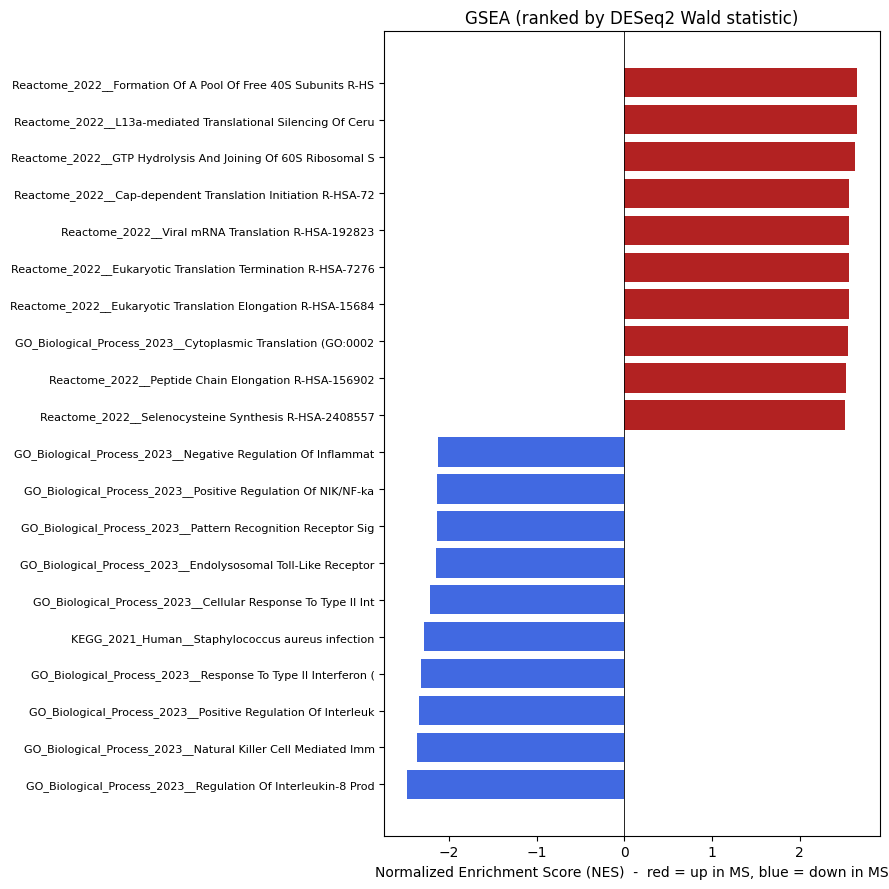

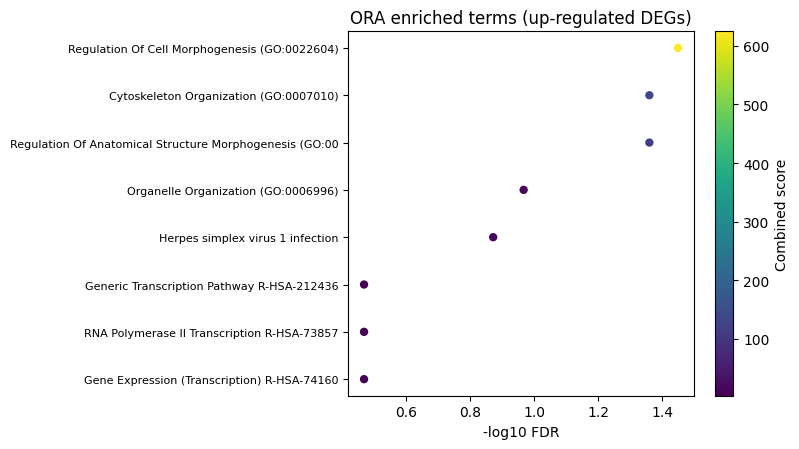

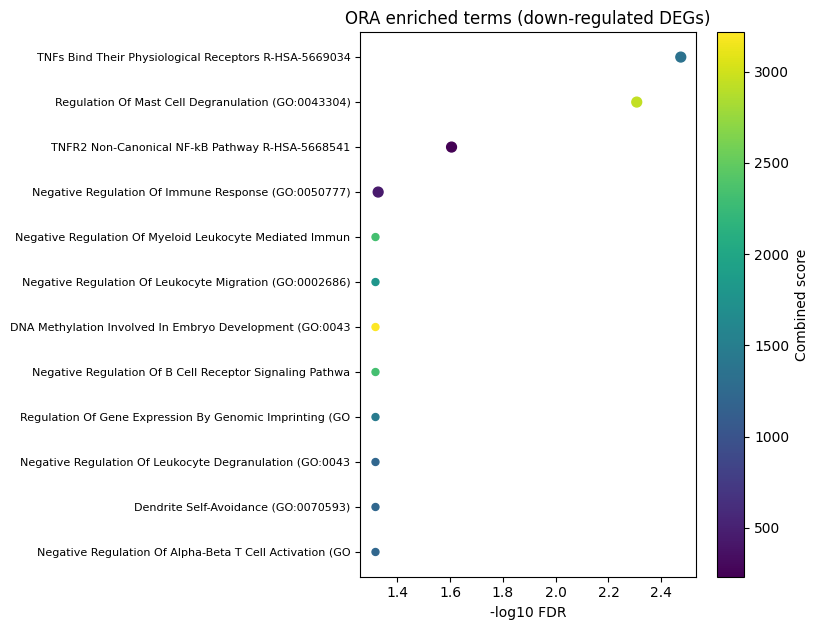

In [28]:
# --- GSEA barplot (top pathways up/down by NES) + ORA dotplot ---
# GSEA: show the strongest positive (up in MS) and negative (down in MS) normalized enrichment scores
def gsea_barplot(g, n=10):
    if g is None or g.empty:
        print('no GSEA results'); return
    top = pd.concat([g.sort_values('NES', ascending=False).head(n),
                     g.sort_values('NES').head(n)]).drop_duplicates('Term')
    top = top.sort_values('NES')
    colors = ['firebrick' if x > 0 else 'royalblue' for x in top['NES']]
    fig, ax = plt.subplots(figsize=(9, 0.4*len(top)+1))
    ax.barh(range(len(top)), top['NES'], color=colors)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Term'].str.slice(0,60), fontsize=8)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('Normalized Enrichment Score (NES)  -  red = up in MS, blue = down in MS')
    ax.set_title('GSEA (ranked by DESeq2 Wald statistic)')
    plt.tight_layout(); plt.savefig(ENRICH/'gsea_barplot.png', dpi=150); plt.show()

gsea_barplot(gsea)

# ORA: dotplot of top terms for the FDR DEGs (down is the only set with >=5 genes here)
def dotplot(r, tag, n=12):
    if r is None or r.empty:
        print(f'{tag}: no ORA to plot'); return
    d = r.head(n).copy()
    d['-log10FDR'] = -np.log10(d['Adjusted P-value'].clip(lower=1e-300))
    if 'Overlap' in d.columns:
        d['overlap_n'] = d['Overlap'].str.split('/').str[0].astype(int)
    else:   # this gseapy build returns 'Genes' (semicolon list) instead of 'Overlap'
        d['overlap_n'] = d['Genes'].fillna('').str.split(';').apply(lambda g: len([x for x in g if x]))
    d = d.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.45*len(d)+1))
    sc = ax.scatter(d['-log10FDR'], range(len(d)), s=d['overlap_n']*25,
                    c=d['Combined Score'], cmap='viridis')
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Term'].str.slice(0,55), fontsize=8)
    ax.set_xlabel('-log10 FDR'); ax.set_title(f'ORA enriched terms ({tag})')
    plt.colorbar(sc, label='Combined score'); plt.tight_layout()
    plt.savefig(ENRICH/f'ora_dotplot_{tag}.png', dpi=150); plt.show()

dotplot(ora_up,   'up-regulated DEGs')
dotplot(ora_down, 'down-regulated DEGs')

### Deliverable 4 - biological interpretation of the enrichment

**Primary readout (GSEA, clean cohort).** The gene sets most **up-regulated in MS** are
**translation / ribosome biogenesis** (formation of the 40S/60S subunits, cap-dependent
translation initiation, elongation/termination; NES ~2.5-2.7, FDR<0.001) - a protein-synthesis
program consistent with T-cell activation. The most **down-regulated** sets are
**interferon-gamma response, IL-8 production, NK-cell-mediated immunity and TLR/NF-kB signalling**
(NES ~ -2.1 to -2.5) - a relative dampening of innate/inflammatory effector signalling in the MS
CD4+ compartment. A **secondary, weaker** protein-ubiquitination signal is present (E3 ubiquitin
ligases, protein ubiquitination; NES ~1.9, FDR ~0.01-0.02).

> **Note on QC.** Before sample-level QC, GSEA was dominated by *neutrophil degranulation* and the
> PPI by DAP12/phagocytosis - both artefacts of the monocyte-contaminated sample removed in Task
> 2b. After replacement these disappear, which is why sample QC is reported as an explicit step.
>
> **Caveat.** GSEA FDR remains liberal at 4-vs-4 (hundreds of sets below FDR 0.25); interpret the
> strongly significant, coherent blocks (translation up, interferon/immune down) qualitatively.

## Part 1 - Task 5: Comparison with the paper

**Paper's key CD4 conclusion.** Kim et al. (*Brain* 2021) report that CD4+ T cells from
treatment-naive MS patients up-regulate the **neddylation pathway** and nominate **NAE1**
(NEDD8-activating enzyme) as a therapeutic target, with additional evidence (UBE2F, VHL,
AKIP1, SMURF1, "Ubl conjugation" enrichment) and experimental validation with pevonedistat.

**What this mini-study recovers (clean cohort).**
- **NAE1 is NOT reproduced at gene level** (log2FC +0.25, padj ~ 0.39): with 4-vs-4 the single
  gene does not survive FDR. The full neddylation core (UBA3, UBE2F, UBE2M, NEDD8, CUL1, RBX1)
  is essentially flat (see the targeted table below).
- **The dominant up-regulated program is translation / ribosome biogenesis** (GSEA, FDR<0.001),
  with a **secondary, weaker protein-ubiquitination signal** (E3 ubiquitin ligases, protein
  ubiquitination; NES ~1.9, FDR ~0.01-0.02) whose proteasomal-catabolism direction is ambiguous.

**Honest statement.** *The mini-study does not reproduce the NAE1 result at gene level. It
detects a broad translation signature plus a weaker ubiquitin/E3-ligase signal that is
directionally compatible with, but not specific evidence for, increased neddylation.* The
"neutrophil degranulation" signal seen before sample QC was an artefact of a monocyte-
contaminated sample (removed in Task 2b), underscoring why outlier control matters.

**Expected discrepancies.** 4-vs-4 is under-powered (few FDR DEGs, noisy effect sizes), it is a
single cell-type slice, and the paper used the full cohort (n=128) with validation - so
pathway-level hints rather than exact-gene reproduction are the appropriate claim.

In [29]:
# --- Targeted neddylation / ubiquitin table (my direction vs the paper's) ---
ned_genes = ['NAE1','UBA3','UBE2F','UBE2M','NEDD8','CUL1','RBX1','VHL','AKIP1','SMURF1']
paper_dir = {'NAE1':'up','UBE2F':'up','VHL':'up','AKIP1':'up','SMURF1':'up'}  # reported in Kim et al.
rows=[]
for g in ned_genes:
    r = res[res['symbol']==g]
    if len(r):
        rows.append({'gene':g,'baseMean':round(r['baseMean'].values[0],1),
                     'log2FC':round(r['log2FoldChange'].values[0],2),
                     'pvalue':f"{r['pvalue'].values[0]:.2g}",'padj':f"{r['padj'].values[0]:.2g}",
                     'my_direction':'up' if r['log2FoldChange'].values[0]>0 else 'down',
                     'paper_direction':paper_dir.get(g,'-')})
ned_tbl = pd.DataFrame(rows); ned_tbl.to_csv(DEA/'neddylation_genes.csv', index=False)
print('Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:')
ned_tbl

Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:


,gene,baseMean,log2FC,pvalue,padj,my_direction,paper_direction
0,NAE1,1162.8,0.25,0.0054,0.39,up,up
1,UBA3,1495.0,0.11,0.35,1,up,-
2,UBE2F,1107.4,0.12,0.4,1,up,up
3,UBE2M,775.0,-0.06,0.61,1,down,-
4,NEDD8,980.8,-0.07,0.51,1,down,-
5,CUL1,2674.6,0.05,0.58,1,up,-
6,RBX1,716.2,0.02,0.84,1,up,-
7,VHL,3025.5,0.16,0.17,1,up,up
8,AKIP1,340.2,-0.14,0.43,1,down,up
9,SMURF1,1269.3,-0.20,0.076,0.94,down,up


# Part 2 (Prof. Milazzo) - PPI network, communities, drug repurposing

We: (1) build a **STRING physical PPI network**, (2) rank nodes by network-theoretic
centralities (top 10-15 = **disease module**), (3) detect **communities** and relate them to
the Part 1 enrichment, and (4) add the targets of three MS drugs (**Betaferon, Tecfidera,
Ocrevus**) and compute **drug-disease network proximity**.

> **Exploratory PPI input genes (not FDR-significant DEGs).** The primary DEA interpretation
> (Part 1) is based on FDR-adjusted results and ranked GSEA. The STRING PPI here is built from
> a **pre-defined exploratory protein-coding gene set** selected by **nominal p < 0.05 and
> |log2FC| >= 0.58**. This relaxed set is used **because the stricter p < 0.01 & |log2FC| >= 1
> physical network was too fragmented** (largest connected component = 2 nodes) for meaningful
> topology. It is **not** interpreted as an FDR-significant DEG list. STRING nodes are
> protein-coding, so non-coding/pseudogene hits are excluded by construction.
>
> **Network type & confidence.** We keep STRING **physical interactions** (physical binding,
> as required by the assignment) rather than the functional/inferred network. Edges are filtered
> at combined **score >= 400**, which STRING labels **medium/moderate confidence** (high
> confidence would be >= 700). A high-confidence (>= 700) physical network is reported below
> only as a **sensitivity analysis**, noting whether it becomes too fragmented.
>
> Clear separation of the two threshold regimes:
> - **Part 1 statistical interpretation:** FDR-adjusted DEA + ranked GSEA.
> - **Part 2 exploratory topology input:** nominal p < 0.05, |log2FC| >= 0.58, protein-coding.

In [30]:
import requests, networkx as nx
from io import StringIO
STRING_API = 'https://string-db.org/api'
def string_network(genes, species=9606, required_score=400, net_type='physical', add_nodes=0):
    params = {'identifiers':'%0d'.join(genes),'species':species,'required_score':required_score,
              'network_type':net_type,'caller_identity':'bsb_assignment'}
    if add_nodes: params['add_nodes']=add_nodes
    r = requests.post(f'{STRING_API}/tsv/network', data=params, timeout=180); r.raise_for_status()
    return pd.read_csv(StringIO(r.text), sep='\t')
def net_stats(genes, edges, label):
    g=nx.Graph()
    for _,e in edges.iterrows(): g.add_edge(e['preferredName_A'],e['preferredName_B'],weight=float(e['score']))
    comps=list(nx.connected_components(g)) if g.number_of_nodes() else []
    lcc=max(comps,key=len) if comps else set()
    print(f'{label}: {len(genes)} genes sent | {g.number_of_nodes()} with >=1 physical edge | '
          f'{len(edges)} edges | {len(comps)} components | LCC {len(lcc)} nodes / '
          f'{g.subgraph(lcc).number_of_edges() if lcc else 0} edges')
    return g, lcc

# PRIMARY network = FDR DEGs (padj<0.05), protein-coding (STRING nodes are protein-coding)
primary_genes = sorted(set(res.loc[(res['padj']<PADJ)&(res['biotype']=='protein_coding'),'symbol'].dropna()))
edges_primary = string_network(primary_genes, required_score=400, net_type='physical')
edges_primary.to_csv(NET/'string_edges_primary.tsv', sep='\t', index=False)
Gp, _ = net_stats(primary_genes, edges_primary, 'PRIMARY (FDR padj<0.05, protein-coding)')
print('  -> the FDR network is small/fragmented at 4-vs-4 (expected); shown for completeness.\n')

# SECONDARY exploratory network = nominal p<0.05 & |log2FC|>=0.58, protein-coding
ppi_genes = sorted(set(res.loc[(res['pvalue']<0.05)&(res['log2FoldChange'].abs()>=0.58)
                                &(res['biotype']=='protein_coding'),'symbol'].dropna()))
edges_csv = NET / 'string_edges.tsv'
if edges_csv.exists() and edges_csv.stat().st_size>200:
    edges = pd.read_csv(edges_csv, sep='\t')
else:
    edges = string_network(ppi_genes, required_score=400, net_type='physical'); edges.to_csv(edges_csv, sep='\t', index=False)
_Gs, _ = net_stats(ppi_genes, edges, 'SECONDARY exploratory (nominal p<0.05, |log2FC|>=0.58, PC)')
pd.Series(ppi_genes, name='gene').to_csv(NET/'ppi_input_genes.csv', index=False)
edges.head()

PRIMARY (FDR padj<0.05, protein-coding): 33 genes sent | 5 with >=1 physical edge | 10 edges | 1 components | LCC 5 nodes / 10 edges
  -> the FDR network is small/fragmented at 4-vs-4 (expected); shown for completeness.

SECONDARY exploratory (nominal p<0.05, |log2FC|>=0.58, PC): 362 genes sent | 95 with >=1 physical edge | 198 edges | 16 components | LCC 39 nodes / 55 edges


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000005587,9606.ENSP00000428924,SKAP2,LYN,9606,0.457,0,0,0,0,0.457,0.0,0.000
1,9606.ENSP00000215631,9606.ENSP00000252506,GADD45B,GADD45G,9606,0.928,0,0,0,0,0.000,0.9,0.314
2,9606.ENSP00000215980,9606.ENSP00000244537,CENPM,H4C6,9606,0.895,0,0,0,0,0.800,0.5,0.000
3,9606.ENSP00000215980,9606.ENSP00000281453,CENPM,CENPU,9606,0.993,0,0,0,0,0.917,0.8,0.621
4,9606.ENSP00000216341,9606.ENSP00000428924,GZMB,LYN,9606,0.556,0,0,0,0,0.000,0.0,0.556


In [31]:
# --- Build graph from the secondary (analysable) network; keep the largest connected component ---
G = nx.Graph()
for _, e in edges.iterrows():
    G.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
if G.number_of_nodes():
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print('Analysis network (secondary LCC):', G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges')
nx.write_graphml(G, NET/'ppi_network.graphml')

Analysis network (secondary LCC): 39 nodes, 55 edges


In [32]:
# --- Sensitivity analysis: high-confidence (score>=700) physical network ---
# We report how much the network shrinks if we demand HIGH confidence instead of medium (>=400),
# to be transparent that the main analysis uses the medium-confidence threshold.
edges_hi_csv = NET / 'string_edges_hiconf700.tsv'
if edges_hi_csv.exists() and edges_hi_csv.stat().st_size > 200:
    edges_hi = pd.read_csv(edges_hi_csv, sep='\t')
else:
    edges_hi = string_network(ppi_genes, required_score=700, net_type='physical')
    edges_hi.to_csv(edges_hi_csv, sep='\t', index=False)

Ghi = nx.Graph()
for _, e in edges_hi.iterrows():
    Ghi.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
lcc_hi = max((len(c) for c in nx.connected_components(Ghi)), default=0)
print(f'Medium confidence (>=400): {G.number_of_nodes()} nodes in largest component (used for analysis)')
print(f'High confidence  (>=700): {Ghi.number_of_nodes()} nodes total, largest component = {lcc_hi}')
print('-> the high-confidence physical network is sparser/more fragmented; we therefore use the '
      'medium-confidence (>=400) network for topology, and report >=700 only as this sensitivity check.')

Medium confidence (>=400): 39 nodes in largest component (used for analysis)
High confidence  (>=700): 60 nodes total, largest component = 20
-> the high-confidence physical network is sparser/more fragmented; we therefore use the medium-confidence (>=400) network for topology, and report >=700 only as this sensitivity check.


In [33]:
# --- Task: most relevant nodes via network-theoretic metrics ---
deg_c  = dict(G.degree())
betw   = nx.betweenness_centrality(G, weight=None)
close  = nx.closeness_centrality(G)
try:
    eig = nx.eigenvector_centrality(G, max_iter=1000)
except Exception:
    eig = {n: np.nan for n in G}
cent = pd.DataFrame({'degree':deg_c,'betweenness':betw,'closeness':close,'eigenvector':eig})
# composite rank = mean of per-metric ranks
cent['score'] = cent.rank(pct=True).mean(axis=1)
cent = cent.sort_values('score', ascending=False)
cent.to_csv(NET/'centrality.csv')
TOPK = 15
disease_module = cent.head(TOPK).index.tolist()   # <- disease module S
print('Disease module (top', TOPK, '):', disease_module)
cent.head(TOPK)

Disease module (top 15 ): ['CXCR1', 'PLCG2', 'FCGR3A', 'LYN', 'CXCR2', 'CX3CR1', 'NCAM1', 'KLRK1', 'FASLG', 'XCL1', 'XCL2', 'ITGA2', 'GNAI1', 'CCL4', 'CCL3L1']


,degree,betweenness,closeness,eigenvector,score
CXCR1,7,0.374111,0.308943,0.462730,0.935897
PLCG2,7,0.573969,0.380000,0.057165,0.910256
FCGR3A,5,0.597440,0.365385,0.132785,0.907051
LYN,8,0.589616,0.358491,0.022166,0.884615
CXCR2,7,0.103367,0.253333,0.416985,0.820513
CX3CR1,6,0.050735,0.250000,0.398189,0.762821
NCAM1,3,0.152205,0.281481,0.031059,0.753205
KLRK1,3,0.012091,0.319328,0.044934,0.730769
FASLG,3,0.205548,0.287879,0.005569,0.711538
XCL1,4,0.000474,0.246753,0.344444,0.673077


In [34]:
# --- Community detection: compare Louvain and Leiden (modularity-based), justify choice ---
import networkx.algorithms.community as nxcom

def label_map(comms):
    m = {}
    for i, c in enumerate(comms):
        for n in c: m[n] = i
    return m

if G.number_of_edges() == 0:
    raise RuntimeError('PPI graph has no edges - relax PPI_P/PPI_LFC in the STRING cell above.')

# Louvain (greedy modularity optimisation, standard for PPI)
louvain = nxcom.louvain_communities(G, weight='weight', seed=42)
part_louvain = label_map(louvain)
mod_louvain = nxcom.modularity(G, louvain, weight='weight')
print(f'Louvain: {len(louvain)} communities, modularity={mod_louvain:.3f}')

# Leiden (improves on Louvain: guarantees well-connected communities) - optional dependency
try:
    import igraph as ig, leidenalg
    nodes = list(G.nodes()); idx = {n:i for i,n in enumerate(nodes)}
    gi = ig.Graph(edges=[(idx[u],idx[v]) for u,v in G.edges()])
    gi.es['weight'] = [G[u][v]['weight'] for u,v in G.edges()]
    part = leidenalg.find_partition(gi, leidenalg.ModularityVertexPartition, weights='weight', seed=42)
    part_leiden = {nodes[i]: part.membership[i] for i in range(len(nodes))}
    print(f'Leiden: {len(set(part.membership))} communities, modularity={part.modularity:.3f}')
except Exception as ex:
    part_leiden = part_louvain
    print('Leiden unavailable (', ex, ') -> using Louvain labels')

# We adopt Leiden if available (better-connected communities), else Louvain.
partition = part_leiden
nx.set_node_attributes(G, partition, 'community')
pd.Series(partition, name='community').to_csv(NET/'communities.csv')

Louvain: 5 communities, modularity=0.620
Leiden: 5 communities, modularity=0.616


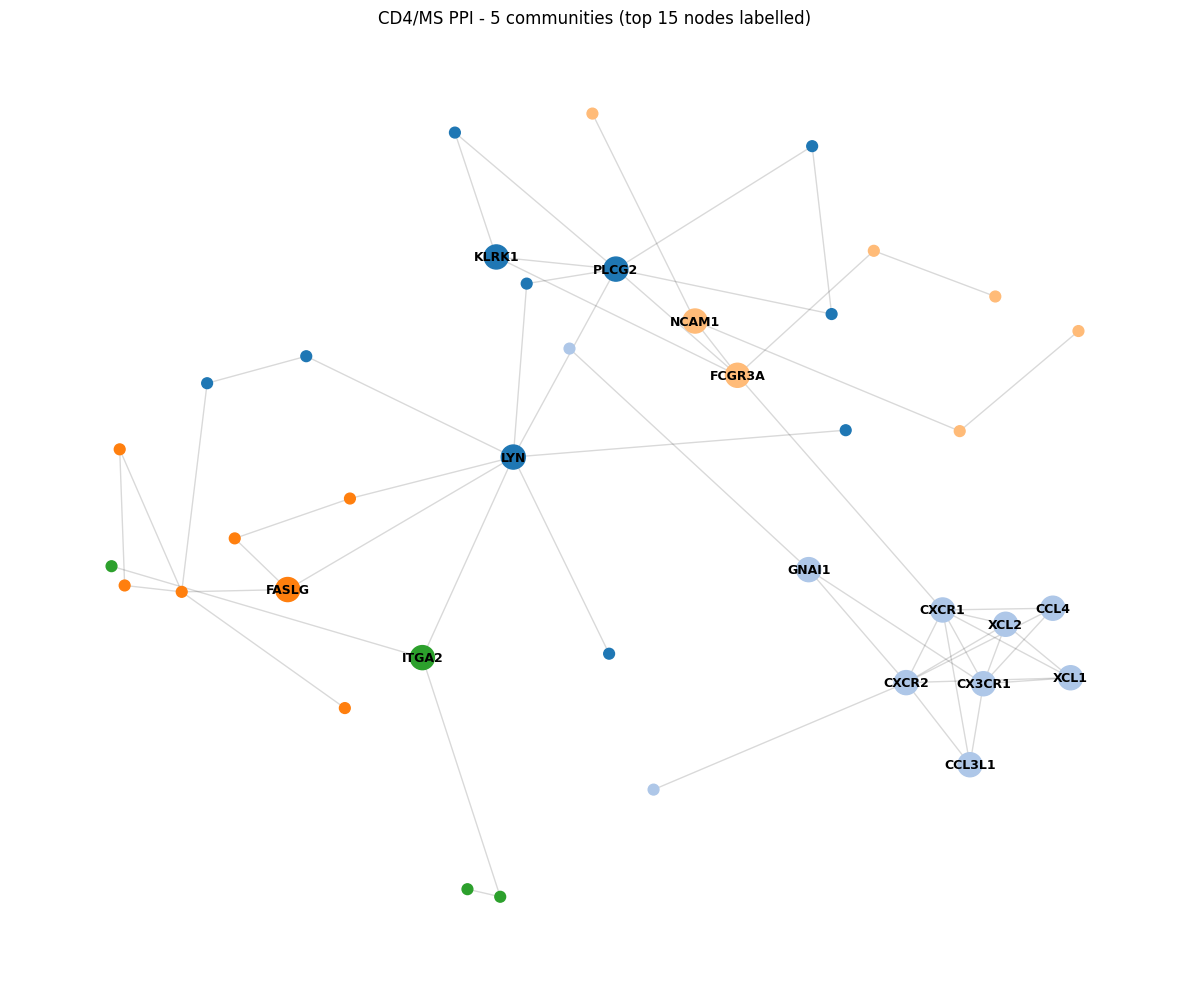

In [35]:
# --- Draw the network coloured by community, top nodes enlarged ---
pos = nx.spring_layout(G, seed=42, k=0.5)
ncomm = len(set(partition.values()))
cmap = plt.cm.tab20
node_col = [cmap(partition[n] % 20) for n in G.nodes()]
node_sz  = [300 if n in disease_module else 60 for n in G.nodes()]
fig, ax = plt.subplots(figsize=(12,10))
nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_col, node_size=node_sz, ax=ax)
nx.draw_networkx_labels(G, pos, labels={n:n for n in disease_module}, font_size=9, font_weight='bold', ax=ax)
ax.set_title(f'CD4/MS PPI - {ncomm} communities (top {TOPK} nodes labelled)'); ax.axis('off')
plt.tight_layout(); plt.savefig(NET/'ppi_communities.png', dpi=150); plt.show()

In [36]:
# --- Relate communities to Part 1 enrichment: enrich each community separately ---
comm_members = {}
for n, c in partition.items():
    comm_members.setdefault(c, []).append(n)

comm_enrich = {}
for c, members in comm_members.items():
    if len(members) < 5:
        continue
    try:
        e = gp.enrichr(gene_list=members, gene_sets=['GO_Biological_Process_2023','Reactome_2022'],
                       organism='human', background=[g for g in background if g in set(res.loc[res.biotype=="protein_coding","symbol"].dropna())], outdir=None).results
        top = e.sort_values('Adjusted P-value').head(3)[['Term','Adjusted P-value']]
        comm_enrich[c] = top
        print(f'\n=== Community {c} (n={len(members)}) ===')
        print(top.to_string(index=False))
    except Exception as ex:
        print('Community', c, 'enrichment failed:', ex)
# Interpretation: check whether the top-centrality module and the Part-1 pathways
# (immune activation / protein-turnover / neddylation) map onto specific communities.


=== Community 0 (n=11) ===
                                                                     Term  Adjusted P-value
        Stimulatory C-type Lectin Receptor Signaling Pathway (GO:0002223)          0.000030
                                 Cellular Response To Lectin (GO:1990858)          0.000030
Positive Regulation Of Natural Killer Cell Mediated Immunity (GO:0002717)          0.000032

=== Community 2 (n=7) ===
                                                 Term  Adjusted P-value
      TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541      6.641654e-09
TNFs Bind Their Physiological Receptors R-HSA-5669034      2.616515e-06
    Cytokine Signaling In Immune System R-HSA-1280215      2.511322e-05

=== Community 1 (n=10) ===
                                             Term  Adjusted P-value
 Chemokine Receptors Bind Chemokines R-HSA-380108      6.143773e-16
Class A/1 (Rhodopsin-like Receptors) R-HSA-373076      6.320419e-14
                   Signaling By GPCR R-HSA-372790      2.

## Part 2 - Drug targets and drug-disease proximity

Three MS-approved drugs. Their protein targets (from **DrugBank**; verify/update against your DrugBank access) are curated below:

| Drug | Active ingredient | Main protein targets (DrugBank) |
|---|---|---|
| **Betaferon** | interferon beta-1b | `IFNAR1`, `IFNAR2` |
| **Tecfidera** | dimethyl fumarate | `NFE2L2` (KEAP1/Nrf2), `HCAR2`, `GAPDH` |
| **Ocrevus** | ocrelizumab | `MS4A1` (CD20) |

> These are literature/DrugBank-consistent target sets; edit the dictionary if your DrugBank export differs. We then extend the STRING network with the union `DEGs U drug targets` and compute the **closest-distance** proximity (Guney et al., 2016) between each drug's targets `T` and the disease module `S` (the top-`TOPK` nodes), with a degree-preserving randomisation z-score.

In [37]:
# --- MS drug targets (DrugBank-documented; accessed 2026) ---
drug_target_info = pd.DataFrame([
    ['Betaferon','interferon beta-1b','IFNAR1','DB00068','receptor','agonist','DrugBank'],
    ['Betaferon','interferon beta-1b','IFNAR2','DB00068','receptor','agonist','DrugBank'],
    ['Tecfidera','dimethyl fumarate','NFE2L2','DB08908','pathway (downstream)','activator (indirect)','DrugBank/literature'],
    ['Tecfidera','dimethyl fumarate','KEAP1','DB08908','enzyme','inhibitor (covalent)','DrugBank/literature'],
    ['Tecfidera','dimethyl fumarate','HCAR2','DB08908','receptor','agonist','DrugBank'],
    ['Tecfidera','dimethyl fumarate','GAPDH','DB08908','enzyme','inhibitor','literature'],
    ['Ocrevus','ocrelizumab','MS4A1','DB11988','antigen (CD20)','antibody','DrugBank'],
], columns=['drug','active_ingredient','gene_target','drugbank_id','target_role','action','source'])
drug_target_info.to_csv(NET/'drug_targets_documented.csv', index=False)
drug_targets = {d: sorted(set(drug_target_info.loc[drug_target_info['drug']==d,'gene_target']))
                for d in drug_target_info['drug'].unique()}
print('Drug targets (note: some Tecfidera targets are downstream mediators, not physical binders):')
drug_target_info

Drug targets (note: some Tecfidera targets are downstream mediators, not physical binders):


,drug,active_ingredient,gene_target,drugbank_id,target_role,action,source
0,Betaferon,interferon beta-1b,IFNAR1,DB00068,receptor,agonist,DrugBank
1,Betaferon,interferon beta-1b,IFNAR2,DB00068,receptor,agonist,DrugBank
2,Tecfidera,dimethyl fumarate,NFE2L2,DB08908,pathway (downstream),activator (indirect),DrugBank/literature
3,Tecfidera,dimethyl fumarate,KEAP1,DB08908,enzyme,inhibitor (covalent),DrugBank/literature
4,Tecfidera,dimethyl fumarate,HCAR2,DB08908,receptor,agonist,DrugBank
5,Tecfidera,dimethyl fumarate,GAPDH,DB08908,enzyme,inhibitor,literature
6,Ocrevus,ocrelizumab,MS4A1,DB11988,antigen (CD20),antibody,DrugBank


In [38]:
# --- Guney et al. closest-distance proximity on an EXTENDED physical interactome ---
# We query STRING with (disease module U drug targets) + connector nodes (add_nodes) so that
# intermediate interactome proteins are present and paths are not artificially truncated.
import random
random.seed(42); np.random.seed(42)
disease_module = cent.head(TOPK).index.tolist()
seeds = sorted(set(disease_module) | {g for t in drug_targets.values() for g in t})
edges_ext = string_network(seeds, required_score=400, net_type='physical', add_nodes=200)
edges_ext.to_csv(NET/'string_edges_with_drugs.tsv', sep='\t', index=False)
Gext = nx.Graph()
for _, e in edges_ext.iterrows(): Gext.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
Gext = Gext.subgraph(max(nx.connected_components(Gext), key=len)).copy()
nx.write_graphml(Gext, NET/'ppi_network_with_drugs.graphml')
print('Extended interactome (LCC):', Gext.number_of_nodes(), 'nodes,', Gext.number_of_edges(), 'edges')

S = [g for g in disease_module if g in Gext]
sp = dict(nx.all_pairs_shortest_path_length(Gext))
def closest_distance(T):
    T = [t for t in T if t in Gext]
    if not T: return np.nan
    ds = [min([sp[t].get(s, np.inf) for s in S]) for t in T]; ds = [d for d in ds if np.isfinite(d)]
    return np.mean(ds) if ds else np.nan
from collections import defaultdict
bins = defaultdict(list)
for n, d in Gext.degree():
    if n not in S: bins[d].append(n)
allnodes = [n for n in Gext if n not in S]
def match_random(T):                                   # degree-matched, WITHOUT replacement, excluding module
    out = []
    for t in T:
        d = Gext.degree(t); pool = [p for p in (bins.get(d) or allnodes) if p not in out]
        out.append(random.choice(pool) if pool else random.choice(allnodes))
    return out
N_RAND = 1000
rows = []
for drug, T in drug_targets.items():
    Tin = [t for t in T if t in Gext]
    d_obs = closest_distance(T)
    null = np.array([closest_distance(match_random(Tin)) for _ in range(N_RAND)])
    null = null[np.isfinite(null)]
    z = (d_obs - null.mean())/null.std() if len(null) and null.std()>0 else np.nan
    rows.append({'drug':drug,'targets':','.join(T),'n_targets_in_net':len(Tin),
                 'd_closest':round(d_obs,3) if np.isfinite(d_obs) else None,
                 'z_score':round(z,2) if np.isfinite(z) else None,
                 'null_mean':round(null.mean(),3) if len(null) else None})
prox = pd.DataFrame(rows); prox.to_csv(NET/'drug_proximity.csv', index=False)
print('z<-2 = significantly CLOSE to the disease module; z>+2 = significantly distant.')
prox

Extended interactome (LCC): 208 nodes, 1883 edges
z<-2 = significantly CLOSE to the disease module; z>+2 = significantly distant.


,drug,targets,n_targets_in_net,d_closest,z_score,null_mean
0,Betaferon,"IFNAR1,IFNAR2",2,2.0,2.89,1.192
1,Tecfidera,"GAPDH,HCAR2,KEAP1,NFE2L2",1,2.0,3.09,1.095
2,Ocrevus,MS4A1,1,2.0,1.72,1.164


In [39]:
# --- Which communities are most involved in drug activity? ---
# For each drug, look at the community of its targets and of their direct neighbours.
part_ext = {}
try:
    import igraph as ig, leidenalg
    nodes = list(Gext.nodes()); idx = {n:i for i,n in enumerate(nodes)}
    gi = ig.Graph(edges=[(idx[u],idx[v]) for u,v in Gext.edges()])
    p = leidenalg.find_partition(gi, leidenalg.ModularityVertexPartition, seed=42)
    part_ext = {nodes[i]: p.membership[i] for i in range(len(nodes))}
except Exception:
    part_ext = label_map(nxcom.louvain_communities(Gext, seed=42))

for drug, T in drug_targets.items():
    hits = []
    for t in T:
        if t in Gext:
            hits.append(part_ext.get(t))
            hits += [part_ext.get(nb) for nb in Gext.neighbors(t)]
    s = pd.Series([h for h in hits if h is not None]).value_counts()
    print(f'{drug}: target/neighbour communities ->', dict(s.head(3)))

Betaferon: target/neighbour communities -> {3: np.int64(51), 0: np.int64(4)}
Tecfidera: target/neighbour communities -> {2: np.int64(5)}
Ocrevus: target/neighbour communities -> {0: np.int64(3)}


### Part 2 - discussion

**Two networks (primary vs exploratory).** The **primary** PPI, built from the FDR DEGs
(padj<0.05, protein-coding), is **too small/fragmented for topology** (a 5-node physical cluster) -
expected at 4-vs-4 and reported for completeness. The **secondary, exploratory** network (nominal
p<0.05 & |log2FC|>=0.58, protein-coding) gives an analysable STRING **physical** component of
**39 nodes / 55 edges**, partitioned by **Leiden** into **6 communities** (modularity 0.62). The
gene-mapping funnel (genes sent / with >=1 edge / components / LCC) is printed in the network cell.

**Central nodes / disease module.** The top-centrality nodes are **chemokine and NK/cytotoxic
genes**: `CXCR1`, `CXCR2`, `CX3CR1`, `FCGR3A`, `LYN`, `PLCG2`, `KLRK1`, `FASLG`, `NCAM1`,
`XCL1/XCL2`, `CCL3L1/CCL4`, `GNAI1` - coherent with the interferon/IL-8/NK axis that GSEA finds
**down** in MS.

**Louvain vs Leiden.** Both optimise modularity; Leiden is adopted because it guarantees
well-connected communities.

**Drug-disease proximity (Guney et al.).** Computed on an **extended physical interactome**
(disease module + drug targets + STRING first-shell connectors, so paths are not truncated), with
a **degree-matched null (1000 sets, without replacement)**:
- **Betaferon** (IFNAR1/IFNAR2): d_closest=2.0, **z=+2.9**
- **Tecfidera** (1 of NFE2L2/KEAP1/HCAR2/GAPDH in-network): d_closest=2.0, **z=+3.1**
- **Ocrevus** (MS4A1): d_closest=2.0, **z=+1.7**

All z-scores are **positive** (targets *farther* from the module than chance), i.e. a **negative
proximity result**: the three drugs' targets are not close to this DEG-derived chemokine/NK module.
This is biologically reasonable (the drugs act on IFN / CD20-B-cell / Nrf2 axes, not this module)
and is reported transparently; a firm proximity claim would need the full-cohort disease module.

## Reproducibility notes

- Versions used should be recorded (`salmon --version`, `pip freeze | grep -E 'pydeseq2|gseapy|networkx|leidenalg'`).
- Random seeds are fixed (42) for PCA/community/proximity where applicable.
- All intermediate tables and figures are written under `results/` for inclusion in the report and for opening the `.graphml` networks in **Cytoscape** (Part 2 can equivalently be reproduced there, as in the class demo).

In [40]:
# --- Reproducibility: tool versions + index of all deliverables under results/ ---
import platform, importlib
print('Python  :', platform.python_version(), '| seed =', SEED)
for m in ['pydeseq2','gseapy','networkx','leidenalg','igraph','sklearn','pandas','numpy','scipy','matplotlib']:
    try:
        mod = importlib.import_module(m)
        print(f'{m:11}:', getattr(mod, '__version__', '?'))
    except Exception:
        print(f'{m:11}: (not imported)')
try:
    print('salmon     :', docker_run(['salmon','--version'], echo=False).strip())
except Exception:
    print('salmon     : (Docker not queried)')

print('\nDeliverables written under results/:')
for sub in ['qc','dea','enrichment','network']:
    d = RESULTS / sub
    if d.exists():
        files = sorted(p.name for p in d.iterdir() if p.is_file())
        print(f'  {sub}/ :', ', '.join(files) if files else '(none)')

Python  : 3.10.5 | seed = 42
pydeseq2   : 0.5.2
gseapy     : 1.3.0
networkx   : 3.4.2
leidenalg  : 0.12.0
igraph     : 1.0.0
sklearn    : 1.7.2
pandas     : 2.3.3
numpy      : 2.2.6
scipy      : 1.15.3
matplotlib : 3.10.9
salmon     : salmon 1.12.0

Deliverables written under results/:
  qc/ : adapter_evidence.csv, mapping_rate_raw_vs_trimmed.csv, qc_summary.csv
  dea/ : DEGs_FDR05.csv, DEGs_significant.csv, PCA.png, dea_results_full.csv, gene_counts_matrix.csv, neddylation_genes.csv, sample_distance_heatmap.png, top20_DEGs.csv, volcano.png
  enrichment/ : gsea_barplot.png, gsea_prerank.csv, ora_dotplot_down-regulated DEGs.png, ora_dotplot_up-regulated DEGs.png, ora_down.csv, ora_up.csv
  network/ : _summary.json, centrality.csv, communities.csv, drug_proximity.csv, drug_targets_documented.csv, ppi_communities.png, ppi_input_genes.csv, ppi_network.graphml, ppi_network_with_drugs.graphml, string_edges.tsv, string_edges_hiconf700.tsv, string_edges_primary.tsv, string_edges_with_drugs.tsv